# Analysis of Real Estate in Georgia
**Summary:** For our Data Science and Analytics Capstone project, our team collaborated with our client Dr. Anca Doloc Mihu to analyze real estate trends in Georgia. Using datasets on healthcare access, labor market indicators, and crime statistics by county, we explored how these factors impact real estate growth. We are planning to analyze our healthcare availability, employment rates, and crime patterns to find potential correlations, offering insights into regional growth dynamics. The findings will be presented through dynamic visualizations and webpage

# Links to Datasets:

Main Dataset(Real Estate): ​The USA Real Estate Dataset taken from Kaggle comprises over 2.2 million real estate listings across the United States, organized by state and ZIP code. It includes details such as property type, price, number of bedrooms and bathrooms, square footage, and address information.
https://www.kaggle.com/datasets/ahmedshahriarsakib/usa-real-estate-dataset

### Three additonal datasets taken from this website: https://georgiadata.org/data/data-tables

Health Dataset: ​The file health_24.xlsx from GeorgiaData.org is part of the Georgia County Guide's health data tables. Provided the link above. These may encompass metrics such as uninsured rates, disease prevalence, mortality rates, and other public health measures across Georgia's 159 counties.
https://georgiadata.org/sites/default/files/health_24.xlsx

Labor Dataset: labor_24.xlsx is a file from GeorgiaData.org that shows job and workforce information for each county in Georgia. It includes things like how many people are working, unemployment rates, and what kinds of jobs people have.
https://georgiadata.org/sites/default/files/labor_24.xlsx

Crime Dataset: ​The file crime_24.xlsx from GeorgiaData.org provides crime statistics for each county in Georgia. It includes data on serious crimes such as murder, robbery, assault, burglary, and theft, helping to understand crime patterns across the state.
https://georgiadata.org/sites/default/files/crime_24.xlsx

Used this dataset for mapping.
https://en.wikipedia.org/wiki/List_of_municipalities_in_Georgia_(U.S._state)









# The more "special properties" there are in a county, the lower the average price of real estate will be (Niko)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df = pd.read_csv('/content/sample_data/GA_RE_cleaned_updated.csv')
df

<ipython-input-2-48ea7cffa333>:1: DtypeWarning: Columns (24,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/sample_data/GA_RE_cleaned_updated.csv')


,Unnamed: 0,status,price,bed,bath,acre_lot,city,zip_code,house_size,prev_sold_date,...,2014 Unemployment Rate,2015 Unemployment Rate,2016 Unemployment Rate,2017 Unemployment Rate,2018 Unemployment Rate,2019 Unemployment Rate,2020 Unemployment Rate,2021 Unemployment Rate,2022 Unemployment Rate,2023 Unemployment Rate
0,0,for_sale,531625.0,5.0,4.0,NaN,Hampton,30228,3661.0,NaN,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
1,1,for_sale,525210.0,5.0,4.0,NaN,Hampton,30228,3661.0,10/31/2022,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
2,2,for_sale,490225.0,5.0,3.0,NaN,Hampton,30228,3116.0,10/27/2022,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
3,3,for_sale,481705.0,5.0,3.0,NaN,Hampton,30228,3116.0,7/20/2022,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
4,4,for_sale,145000.0,NaN,NaN,0.91,Lincolnton,30817,NaN,NaN,...,8.30%,6.90%,6.00%,5.30%,5.00%,4.00%,5.40%,4.10%,3.60%,3.80%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36420,36420,for_sale,149900.0,4.0,1.0,0.64,Whigham,39897,1994.0,NaN,...,7.40%,6.10%,5.50%,4.90%,3.90%,3.50%,4.40%,3.20%,3.10%,3.10%
36421,36421,for_sale,137889.0,3.0,2.0,2.30,Whigham,39897,1458.0,12/3/1999,...,7.40%,6.10%,5.50%,4.90%,3.90%,3.50%,4.40%,3.20%,3.10%,3.10%
36422,36422,for_sale,25000.0,NaN,NaN,3.00,Albany,31721,NaN,3/26/2010,...,9.30%,7.90%,6.90%,6.10%,5.40%,4.80%,8.60%,6.30%,4.50%,4.30%
36423,36423,for_sale,635000.0,NaN,NaN,1.35,Suwanee,30024,NaN,5/11/2022,...,6.10%,5.30%,4.80%,4.30%,3.60%,3.20%,6.30%,3.50%,2.80%,2.90%


In [ ]:
df.drop(columns=['Unnamed: 0'], inplace=True)
df

,status,price,bed,bath,acre_lot,city,zip_code,house_size,prev_sold_date,Special_property,...,2014 Unemployment Rate,2015 Unemployment Rate,2016 Unemployment Rate,2017 Unemployment Rate,2018 Unemployment Rate,2019 Unemployment Rate,2020 Unemployment Rate,2021 Unemployment Rate,2022 Unemployment Rate,2023 Unemployment Rate
0,for_sale,531625.0,5.0,4.0,NaN,Hampton,30228,3661.0,NaN,False,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
1,for_sale,525210.0,5.0,4.0,NaN,Hampton,30228,3661.0,10/31/2022,False,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
2,for_sale,490225.0,5.0,3.0,NaN,Hampton,30228,3116.0,10/27/2022,False,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
3,for_sale,481705.0,5.0,3.0,NaN,Hampton,30228,3116.0,7/20/2022,False,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
4,for_sale,145000.0,NaN,NaN,0.91,Lincolnton,30817,NaN,NaN,True,...,8.30%,6.90%,6.00%,5.30%,5.00%,4.00%,5.40%,4.10%,3.60%,3.80%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36420,for_sale,149900.0,4.0,1.0,0.64,Whigham,39897,1994.0,NaN,False,...,7.40%,6.10%,5.50%,4.90%,3.90%,3.50%,4.40%,3.20%,3.10%,3.10%
36421,for_sale,137889.0,3.0,2.0,2.30,Whigham,39897,1458.0,12/3/1999,False,...,7.40%,6.10%,5.50%,4.90%,3.90%,3.50%,4.40%,3.20%,3.10%,3.10%
36422,for_sale,25000.0,NaN,NaN,3.00,Albany,31721,NaN,3/26/2010,True,...,9.30%,7.90%,6.90%,6.10%,5.40%,4.80%,8.60%,6.30%,4.50%,4.30%
36423,for_sale,635000.0,NaN,NaN,1.35,Suwanee,30024,NaN,5/11/2022,True,...,6.10%,5.30%,4.80%,4.30%,3.60%,3.20%,6.30%,3.50%,2.80%,2.90%


In [ ]:
plot_df = df.groupby('County').agg(SP_count = ('Special_property', 'sum'), avg_value = ('price', 'mean'))
plot_df

,SP_count,avg_value
County,,
Appling,20,250019.534884
Atkinson,1,195133.000000
Bacon,10,356860.227273
Baker,1,45000.000000
Baldwin,108,223359.266667
...,...,...
Whitfield,113,301460.594249
Wilcox,4,252092.857143
Wilkes,12,350961.875000


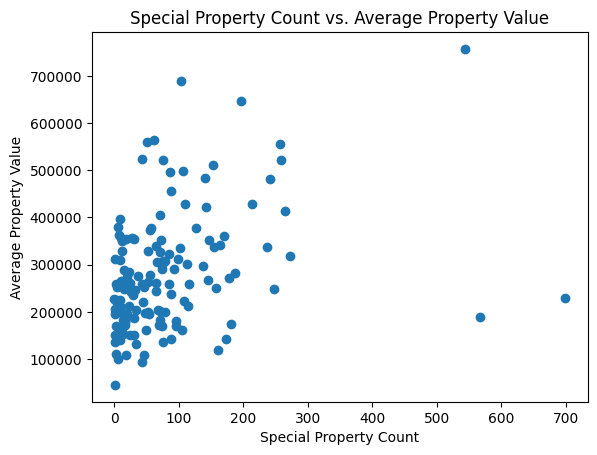

In [ ]:
# Plot comparing the number of "special properties" to the average cost of real estate per county to see if there
# is any correlation.
plt.scatter(plot_df['SP_count'], plot_df['avg_value'])
plt.xlabel('Special Property Count')
plt.ylabel('Average Property Value')
plt.title('Special Property Count vs. Average Property Value')
plt.show()

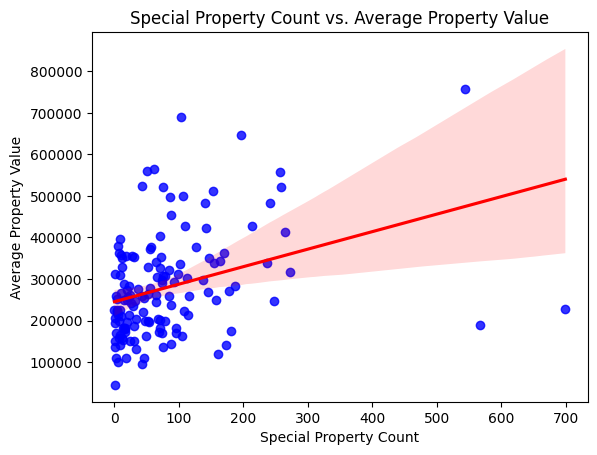

In [ ]:
# Using linear regression to see more clearly what is going in here. Due to how shallow the incline is, and the fact that
# most data points fall outside the confidence interval, it is safe to say there is little to no correlation
# between the number of "special properties" and the average cost of real estate.
sns.regplot(x=plot_df['SP_count'], y=plot_df['avg_value'], scatter_kws={'color': 'blue'}, line_kws={'color': 'red'})
plt.xlabel('Special Property Count')
plt.ylabel('Average Property Value')
plt.title('Special Property Count vs. Average Property Value')
plt.show()

In [ ]:
# Finding the correlation coefficient to further support my claim
correlation_matrix_1 = np.corrcoef(plot_df['SP_count'], plot_df['avg_value'])
correlation_1 = correlation_matrix_1[0, 1]
print(correlation_1)

0.3437061308718002


In [ ]:
plot_df['SP_ratio'] = df.groupby('County')['Special_property'].sum() / df.groupby('County')['County'].count()
plot_df

,SP_count,avg_value,SP_ratio
County,,,
Appling,20,250019.534884,0.465116
Atkinson,1,195133.000000,0.333333
Bacon,10,356860.227273,0.454545
Baker,1,45000.000000,1.000000
Baldwin,108,223359.266667,0.450000
...,...,...,...
Whitfield,113,301460.594249,0.361022
Wilcox,4,252092.857143,0.285714
Wilkes,12,350961.875000,0.375000


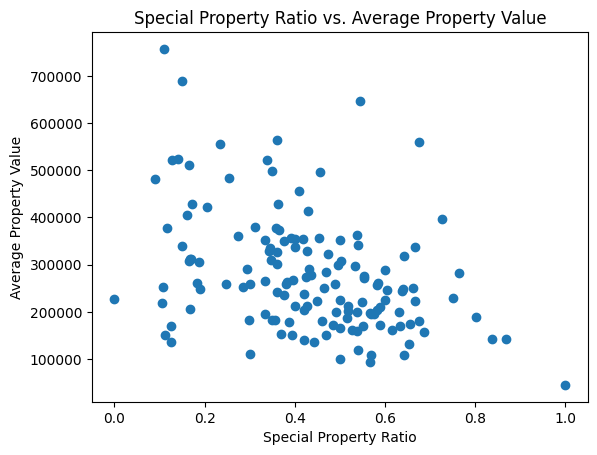

In [ ]:
# Plot to see if there is a correlation between the ratio of special properties
plt.scatter(plot_df['SP_ratio'], plot_df['avg_value'])
plt.xlabel('Special Property Ratio')
plt.ylabel('Average Property Value')
plt.title('Special Property Ratio vs. Average Property Value')
plt.show()

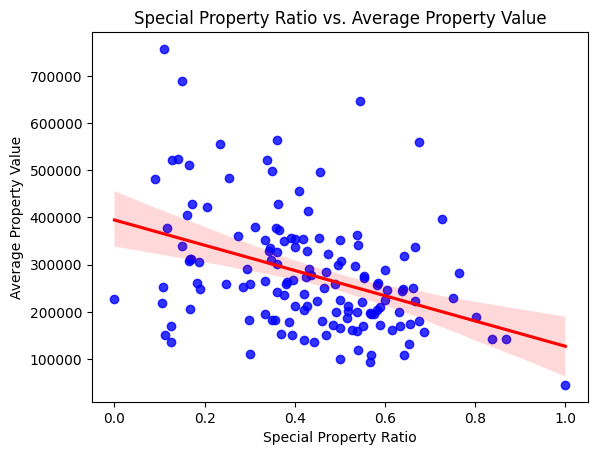

In [ ]:
sns.regplot(x=plot_df['SP_ratio'], y=plot_df['avg_value'], scatter_kws={'color': 'blue'}, line_kws={'color': 'red'})
plt.xlabel('Special Property Ratio')
plt.ylabel('Average Property Value')
plt.title('Special Property Ratio vs. Average Property Value')
plt.show()

In [ ]:
correlaton_matrix = np.corrcoef(plot_df['SP_ratio'], plot_df['avg_value'])
correlaton = correlaton_matrix[0, 1]
print(correlaton)

-0.39488916648686095


As we can see above, there is generally not a very strong correlation between average price and either the number of special properties or the ratio of special properties. Both methods produce correlation coefficients of 0.3437 and -0.3949 respectively, which both indicate that while there may be a correlation, it is relatively weak.

# Property located near major cities will have a higher average price (Niko)

In [ ]:
import folium as fl
import branca as bc
import geopandas as gpd
import pandas as pd
from geopy.geocoders import Nominatim
import time

## Finding the ten largest cities in Georgia

In [ ]:
# Pulling data from wiki page on Georgia municipalities
GA_tables = pd.read_html("https://en.wikipedia.org/wiki/List_of_municipalities_in_Georgia_%28U.S._state%29")
GA_tables

[               Name Type[1]         County[1] Population (2020)[3]  \
                Name Type[1]         County[1] Population (2020)[3]   
 0       Abbeville †    City            Wilcox                 2685   
 1           Acworth    City              Cobb                22440   
 2       Adairsville    City            Bartow                 4878   
 3            Adel †    City              Cook                 5571   
 4            Adrian    City  Emanuel, Johnson                  552   
 ..              ...     ...               ...                  ...   
 534           Wrens    City         Jefferson                 2217   
 535  Wrightsville †    City           Johnson                 3449   
 536      Yatesville    Town             Upson                  394   
 537    Young Harris    City             Towns                 1098   
 538       Zebulon †    City              Pike                 1225   
 
     Population (2010)[3] Change (%) Land area (2010)[1]        \
     Popu

In [ ]:
# Selecting the specific table that relates to cities
GA_Cities = GA_tables[0]
GA_Cities

Name Type[1]         County[1] Population (2020)[3]  \
               Name Type[1]         County[1] Population (2020)[3]   
0       Abbeville †    City            Wilcox                 2685   
1           Acworth    City              Cobb                22440   
2       Adairsville    City            Bartow                 4878   
3            Adel †    City              Cook                 5571   
4            Adrian    City  Emanuel, Johnson                  552   
..              ...     ...               ...                  ...   
534           Wrens    City         Jefferson                 2217   
535  Wrightsville †    City           Johnson                 3449   
536      Yatesville    Town             Upson                  394   
537    Young Harris    City             Towns                 1098   
538       Zebulon †    City              Pike                 1225   

    Population (2010)[3] Change (%) Land area (2010)[1]        \
    Population (2010)[3] Change (%)               sq mi   km2   
0                   2908      −7.7%                3.06   7.9   
1                  20425      +9.9%                8.24  21.3   
2                   4648      +4.9%                9.11  23.6   
3                   5334      +4.4%                8.06  20.9   
4                    664     −16.9%                1.37   3.5   
..                   ...        ...                 ...   ...   
534                 2187      +1.4%                3.13   8.1   
535                 2195     +57.1%                3.52   9.1   
536                  357     +10.4%                0.86   2.2   
537                  899     +22.1%                1.06   2.7   
538                 1174      +4.3%                4.46  11.6   

              Population density  
              Population density  
0        877.5/sq mi (338.8/km2)  
1    2,723.3/sq mi (1,051.5/km2)  
2        535.5/sq mi (206.7/km2)  
3        691.2/sq mi (266.9/km2)  
4        402.9/sq mi (155.6/km2)  
..                           ...  
534      708.3/sq mi (273.5/km2)  
535      979.8/sq mi (378.3/km2)  
536      458.1/sq mi (176.9/km2)  
537    1,035.8/sq mi (399.9/km2)  
538      274.7/sq mi (106.0/km2)  

[539 rows x 9 columns]

In [ ]:
# Selecting relevant columns and adding a sequential column to use as index
GA_Cities = GA_Cities[['Name', 'Type[1]', 'County[1]', 'Population (2020)[3]']]
GA_Cities.insert(0, 'ID', range(1, 1 + len(GA_Cities)))
GA_Cities

,ID,Name,Type[1],County[1],Population (2020)[3]
,,Name,Type[1],County[1],Population (2020)[3]
0,1,Abbeville †,City,Wilcox,2685
1,2,Acworth,City,Cobb,22440
2,3,Adairsville,City,Bartow,4878
3,4,Adel †,City,Cook,5571
4,5,Adrian,City,"Emanuel, Johnson",552
...,...,...,...,...,...
534,535,Wrens,City,Jefferson,2217
535,536,Wrightsville †,City,Johnson,3449
536,537,Yatesville,Town,Upson,394


In [ ]:
# Setting ID column as index
GA_Cities.set_index('ID', inplace = True)
GA_Cities

,Name,Type[1],County[1],Population (2020)[3]
,Name,Type[1],County[1],Population (2020)[3]
ID,,,,
1,Abbeville †,City,Wilcox,2685
2,Acworth,City,Cobb,22440
3,Adairsville,City,Bartow,4878
4,Adel †,City,Cook,5571
5,Adrian,City,"Emanuel, Johnson",552
...,...,...,...,...
535,Wrens,City,Jefferson,2217
536,Wrightsville †,City,Johnson,3449


In [ ]:
# going down to the base level of hierarchy, filtering the dataframe to only include cities, and renaming columns
GA_Cities.columns = GA_Cities.columns.get_level_values(0)
GA_Cities = GA_Cities.loc[GA_Cities['Type[1]'] == 'City']
GA_Cities.rename(columns = {'Name':'City', 'County[1]':'County', 'Population (2020)[3]':'Population'}, inplace = True)
GA_Cities.drop(columns = ['Type[1]'], inplace = True)
GA_Cities

<ipython-input-7-7cbd03e002af>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  GA_Cities.rename(columns = {'Name':'City', 'County[1]':'County', 'Population (2020)[3]':'Population'}, inplace = True)
<ipython-input-7-7cbd03e002af>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  GA_Cities.drop(columns = ['Type[1]'], inplace = True)


,City,County,Population
ID,,,
1,Abbeville †,Wilcox,2685
2,Acworth,Cobb,22440
3,Adairsville,Bartow,4878
4,Adel †,Cook,5571
5,Adrian,"Emanuel, Johnson",552
...,...,...,...
533,Woodville,Greene,264
535,Wrens,Jefferson,2217
536,Wrightsville †,Johnson,3449


In [ ]:
# Using regex to remove any unwanted characters
GA_Cities = GA_Cities.replace(r'[†‡]|,.*|\(seat\)|\s*', '', regex = True)
GA_Cities

,City,County,Population
ID,,,
1,Abbeville,Wilcox,2685
2,Acworth,Cobb,22440
3,Adairsville,Bartow,4878
4,Adel,Cook,5571
5,Adrian,Emanuel,552
...,...,...,...
533,Woodville,Greene,264
535,Wrens,Jefferson,2217
536,Wrightsville,Johnson,3449


In [ ]:
# Sorting dataframe by population from highest to lowest
GA_Cities.sort_values(by=['Population'], ascending=False, inplace=True)
GA_Cities

,City,County,Population
ID,,,
28,Atlanta,Fulton,498715
429,Savannah,Chatham,147780
425,SandySprings,Fulton,108080
445,SouthFulton[11],Fulton,107436
419,Roswell,Fulton,92833
...,...,...,...
457,Summertown,Emanuel,121
434,Sharon,Taliaferro,104
501,Vidette,Burke,103


In [ ]:
# Using head to get the top ten rows, thus getting the ten most populated cities
top_10 = GA_Cities.head(10)
top_10

,City,County,Population
ID,,,
28,Atlanta,Fulton,498715
429,Savannah,Chatham,147780
425,SandySprings,Fulton,108080
445,SouthFulton[11],Fulton,107436
419,Roswell,Fulton,92833
261,JohnsCreek[f],Fulton,82453
511,WarnerRobins,Houston,80308
9,Albany,Dougherty,69647
14,Alpharetta,Fulton,65818


In [ ]:
# Removing more unwanted characters. This is necessary for later to ensure the city names match with the source
# geopy uses to get the coordinates
top_10 = top_10.replace(r'\[(\w+)\]', '', regex=True)
top_10

,City,County,Population
ID,,,
28,Atlanta,Fulton,498715
429,Savannah,Chatham,147780
425,SandySprings,Fulton,108080
445,SouthFulton,Fulton,107436
419,Roswell,Fulton,92833
261,JohnsCreek,Fulton,82453
511,WarnerRobins,Houston,80308
9,Albany,Dougherty,69647
14,Alpharetta,Fulton,65818


In [ ]:
# Splitting city names that are unnecessarily concatenated, again, to ensure they match with geopy
top_10['City'] = top_10['City'].str.replace(r'([a-z])([A-Z])', r'\1 \2', regex=True)
top_10

,City,County,Population
ID,,,
28,Atlanta,Fulton,498715
429,Savannah,Chatham,147780
425,Sandy Springs,Fulton,108080
445,South Fulton,Fulton,107436
419,Roswell,Fulton,92833
261,Johns Creek,Fulton,82453
511,Warner Robins,Houston,80308
9,Albany,Dougherty,69647
14,Alpharetta,Fulton,65818


In [ ]:
# Using Nominatim from geopy to get the coordinates for each city so they can be added as pins on the map later
geolocator = Nominatim(user_agent="geolocator")

def get_coordinates(city):
    try:
        location = geolocator.geocode(city + ", Georgia")
        if location:
            return location.latitude, location.longitude
        else:
            return None, None
    except Exception as e:
        print(f"Error retrieving {city}: {e}")
        return None, None

top_10[['Latitude', 'Longitude']] = top_10['City'].apply(lambda city: pd.Series(get_coordinates(city)))

time.sleep(1)

top_10

,City,County,Population,Latitude,Longitude
ID,,,,,
28,Atlanta,Fulton,498715,33.748992,-84.390264
429,Savannah,Chatham,147780,32.079007,-81.092134
425,Sandy Springs,Fulton,108080,33.924269,-84.378538
445,South Fulton,Fulton,107436,33.590266,-84.671229
419,Roswell,Fulton,92833,34.023320,-84.360022
261,Johns Creek,Fulton,82453,34.018156,-84.190196
511,Warner Robins,Houston,80308,32.620097,-83.606568
9,Albany,Dougherty,69647,31.578206,-84.155681
14,Alpharetta,Fulton,65818,34.070958,-84.274733


## Mapping counties by average price and pinning cities

In [ ]:
# Creating dataframe using shapefile and geopandas
gdf = gpd.read_file('cb_2020_us_county_500k.shp')
gdf

,STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry
0,13,031,00350302,0500000US13031,13031,Bulloch,Bulloch County,GA,Georgia,06,1750735216,32827779,"POLYGON ((-82.02684 32.55516, -82.02527 32.558..."
1,13,121,01694833,0500000US13121,13121,Fulton,Fulton County,GA,Georgia,06,1364133162,19666288,"POLYGON ((-84.84931 33.51318, -84.84429 33.514..."
2,13,179,00357095,0500000US13179,13179,Liberty,Liberty County,GA,Georgia,06,1337654102,222884791,"POLYGON ((-81.8244 32.01488, -81.81338 32.0162..."
3,13,189,00348794,0500000US13189,13189,McDuffie,McDuffie County,GA,Georgia,06,666590014,23114032,"POLYGON ((-82.64852 33.60838, -82.64409 33.606..."
4,13,213,01688005,0500000US13213,13213,Murray,Murray County,GA,Georgia,06,892235145,5719644,"POLYGON ((-84.94434 34.68004, -84.9431 34.6804..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3229,21,073,00516883,0500000US21073,21073,Franklin,Franklin County,KY,Kentucky,06,538312209,10786432,"POLYGON ((-85.02426 38.13059, -85.02299 38.131..."
3230,17,201,01785216,0500000US17201,17201,Winnebago,Winnebago County,IL,Illinois,06,1328792556,15873993,"POLYGON ((-89.40142 42.50043, -89.37175 42.500..."
3231,17,123,00424260,0500000US17123,17123,Marshall,Marshall County,IL,Illinois,06,1001843226,30364348,"POLYGON ((-89.63869 40.98691, -89.63868 40.988..."
3232,37,185,01008593,0500000US37185,37185,Warren,Warren County,NC,North Carolina,06,1112117461,38615564,"POLYGON ((-78.32391 36.54381, -78.313 36.54388..."


In [ ]:
# Filtering dataframe down to only cities in Georgia
gdf = gdf[gdf['STUSPS'] == 'GA']
gdf

,STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry
0,13,031,00350302,0500000US13031,13031,Bulloch,Bulloch County,GA,Georgia,06,1750735216,32827779,"POLYGON ((-82.02684 32.55516, -82.02527 32.558..."
1,13,121,01694833,0500000US13121,13121,Fulton,Fulton County,GA,Georgia,06,1364133162,19666288,"POLYGON ((-84.84931 33.51318, -84.84429 33.514..."
2,13,179,00357095,0500000US13179,13179,Liberty,Liberty County,GA,Georgia,06,1337654102,222884791,"POLYGON ((-81.8244 32.01488, -81.81338 32.0162..."
3,13,189,00348794,0500000US13189,13189,McDuffie,McDuffie County,GA,Georgia,06,666590014,23114032,"POLYGON ((-82.64852 33.60838, -82.64409 33.606..."
4,13,213,01688005,0500000US13213,13213,Murray,Murray County,GA,Georgia,06,892235145,5719644,"POLYGON ((-84.94434 34.68004, -84.9431 34.6804..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3175,13,129,00356672,0500000US13129,13129,Gordon,Gordon County,GA,Georgia,06,923182601,5729235,"POLYGON ((-85.1114 34.46338, -85.09007 34.4635..."
3176,13,095,00351259,0500000US13095,13095,Dougherty,Dougherty County,GA,Georgia,06,851183381,15352851,"POLYGON ((-84.45766 31.58404, -84.45687 31.586..."
3183,13,295,00354216,0500000US13295,13295,Walker,Walker County,GA,Georgia,06,1156145202,1672676,"POLYGON ((-85.53409 34.62386, -85.4908 34.6694..."
3199,13,175,00346568,0500000US13175,13175,Laurens,Laurens County,GA,Georgia,06,2090990042,28838468,"POLYGON ((-83.22654 32.5842, -83.20872 32.5929..."


In [ ]:
df = pd.read_csv('GA_RE_cleaned_updated.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)
df

<ipython-input-15-2323fbaf9c28>:1: DtypeWarning: Columns (24,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('GA_RE_cleaned_updated.csv')


,status,price,bed,bath,acre_lot,city,zip_code,house_size,prev_sold_date,Special_property,...,2014 Unemployment Rate,2015 Unemployment Rate,2016 Unemployment Rate,2017 Unemployment Rate,2018 Unemployment Rate,2019 Unemployment Rate,2020 Unemployment Rate,2021 Unemployment Rate,2022 Unemployment Rate,2023 Unemployment Rate
0,for_sale,531625.0,5.0,4.0,NaN,Hampton,30228,3661.0,NaN,False,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
1,for_sale,525210.0,5.0,4.0,NaN,Hampton,30228,3661.0,10/31/2022,False,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
2,for_sale,490225.0,5.0,3.0,NaN,Hampton,30228,3116.0,10/27/2022,False,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
3,for_sale,481705.0,5.0,3.0,NaN,Hampton,30228,3116.0,7/20/2022,False,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
4,for_sale,145000.0,NaN,NaN,0.91,Lincolnton,30817,NaN,NaN,True,...,8.30%,6.90%,6.00%,5.30%,5.00%,4.00%,5.40%,4.10%,3.60%,3.80%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36420,for_sale,149900.0,4.0,1.0,0.64,Whigham,39897,1994.0,NaN,False,...,7.40%,6.10%,5.50%,4.90%,3.90%,3.50%,4.40%,3.20%,3.10%,3.10%
36421,for_sale,137889.0,3.0,2.0,2.30,Whigham,39897,1458.0,12/3/1999,False,...,7.40%,6.10%,5.50%,4.90%,3.90%,3.50%,4.40%,3.20%,3.10%,3.10%
36422,for_sale,25000.0,NaN,NaN,3.00,Albany,31721,NaN,3/26/2010,True,...,9.30%,7.90%,6.90%,6.10%,5.40%,4.80%,8.60%,6.30%,4.50%,4.30%
36423,for_sale,635000.0,NaN,NaN,1.35,Suwanee,30024,NaN,5/11/2022,True,...,6.10%,5.30%,4.80%,4.30%,3.60%,3.20%,6.30%,3.50%,2.80%,2.90%


In [ ]:
# Creating a dataframe containing only the information relevant to the hypothesis
plot_df2 = df.groupby('County').agg(avg_value = ('price', 'mean')).reset_index()
plot_df2

,County,avg_value
0,Appling,250019.534884
1,Atkinson,195133.000000
2,Bacon,356860.227273
3,Baker,45000.000000
4,Baldwin,223359.266667
...,...,...
137,Whitfield,301460.594249
138,Wilcox,252092.857143
139,Wilkes,350961.875000
140,Wilkinson,156823.750000


In [ ]:
# Merging the shapefile dataframe with the previously created dataframe on the 'County' column
gdf = gdf.merge(plot_df2, left_on='NAME', right_on='County')
gdf

,STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry,County,avg_value
0,13,031,00350302,0500000US13031,13031,Bulloch,Bulloch County,GA,Georgia,06,1750735216,32827779,"POLYGON ((-82.02684 32.55516, -82.02527 32.558...",Bulloch,335979.566102
1,13,121,01694833,0500000US13121,13121,Fulton,Fulton County,GA,Georgia,06,1364133162,19666288,"POLYGON ((-84.84931 33.51318, -84.84429 33.514...",Fulton,757430.577340
2,13,179,00357095,0500000US13179,13179,Liberty,Liberty County,GA,Georgia,06,1337654102,222884791,"POLYGON ((-81.8244 32.01488, -81.81338 32.0162...",Liberty,271160.440625
3,13,213,01688005,0500000US13213,13213,Murray,Murray County,GA,Georgia,06,892235145,5719644,"POLYGON ((-84.94434 34.68004, -84.9431 34.6804...",Murray,212639.563636
4,13,209,00352276,0500000US13209,13209,Montgomery,Montgomery County,GA,Georgia,06,624563058,9191488,"POLYGON ((-82.65581 32.3015, -82.65291 32.3033...",Montgomery,235209.675325
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137,13,115,00353665,0500000US13115,13115,Floyd,Floyd County,GA,Georgia,06,1320404595,22414013,"POLYGON ((-85.46208 34.28639, -85.43522 34.286...",Floyd,268213.970027
138,13,129,00356672,0500000US13129,13129,Gordon,Gordon County,GA,Georgia,06,923182601,5729235,"POLYGON ((-85.1114 34.46338, -85.09007 34.4635...",Gordon,522257.624434
139,13,095,00351259,0500000US13095,13095,Dougherty,Dougherty County,GA,Georgia,06,851183381,15352851,"POLYGON ((-84.45766 31.58404, -84.45687 31.586...",Dougherty,118591.378378
140,13,295,00354216,0500000US13295,13295,Walker,Walker County,GA,Georgia,06,1156145202,1672676,"POLYGON ((-85.53409 34.62386, -85.4908 34.6694...",Walker,291468.342742


In [ ]:
# Checking which Coordinate Reference System (CRS) is being used, as it must be a specific type to work with GeoJSON
# which is what will be used to create the map
print("Initial CRS: " + str(gdf.crs))

Initial CRS: None


In [ ]:
# Setting CRS and checking to ensure it set correctly. EPSG:4326 is the standard longitude/latitude system that is
# used for most forms of mapping
gdf = gdf.set_crs(epsg=4326, inplace=True)
print("CRS Check: " + str(gdf.crs))

CRS Check: EPSG:4326


In [ ]:
# Using branca to create a color scale for the heatmap
colormap = bc.colormap.linear.YlGnBu_09.scale(gdf['avg_value'].min(), gdf['avg_value'].max())

In [ ]:
# Defining how to fill in the map. If a county has no data, it will be filled inas gray, otherwise it will use
# the colormap
def style_function(feature):
    avg_cost = feature['properties']['avg_value']

    if avg_cost is None:
        return {'fillColor': 'gray', 'color': 'gray', 'weight': 1, 'fillOpacity': 0.7}

    color = colormap(avg_cost)

    return {
        'fillColor': color,
        'color': color,
        'weight': 1,
        'fillOpacity': 0.5
    }

In [ ]:
# Using folium to create the map and center it at Georgia
georgia_map = fl.Map(location=[33.7490, -84.3880], zoom_start=7)

In [ ]:
# Using GeoJSON to fill in the map. This is where it was necessary to set the appropriate CRS, otherwise it would
#not work with GeoJSON.
fl.GeoJson(
    gdf,
    style_function=style_function,
    tooltip=fl.GeoJsonTooltip(fields=['NAME', 'avg_value'], aliases=['County', 'avg_value'])
).add_to(georgia_map)

In [ ]:
# Adding the color scale to the map to be used as a legend
colormap.add_to(georgia_map)

In [ ]:
# Iterating through the dataframe containing the top ten populated cities and adding them to the map, along with
# editing the marker to show data such as city name and population when clicked on.
for index, row in top_10.iterrows():
    city_name = row['City']
    population = row['Population']
    lat = row['Latitude']
    lon = row['Longitude']

    fl.Marker(
        location=[lat, lon],
        popup=f"{city_name}: {population} people",
        icon=fl.Icon(color='blue', icon='info-sign')
    ).add_to(georgia_map)

In [ ]:
georgia_map.save('georgia_counties_map.html')

As is evident from the map, while there are a few exceptions, the areas around major cities show a signifcantly higher average price for real estate. Since highly populated cities are likely to be more desirable, it stands to reason that the real estate in and around those cities would be worth more.

# Work on Dataset (Nazmun)

In [ ]:
df = pd.read_csv('/content/sample_data/GA_RE_cleaned_updated.csv')
df.head()

<ipython-input-4-0eedbcc4ec15>:1: DtypeWarning: Columns (24,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/sample_data/GA_RE_cleaned_updated.csv')


,Unnamed: 0,status,price,bed,bath,acre_lot,city,zip_code,house_size,prev_sold_date,...,2014 Unemployment Rate,2015 Unemployment Rate,2016 Unemployment Rate,2017 Unemployment Rate,2018 Unemployment Rate,2019 Unemployment Rate,2020 Unemployment Rate,2021 Unemployment Rate,2022 Unemployment Rate,2023 Unemployment Rate
0,0,for_sale,531625.0,5.0,4.0,NaN,Hampton,30228,3661.0,NaN,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
1,1,for_sale,525210.0,5.0,4.0,NaN,Hampton,30228,3661.0,10/31/2022,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
2,2,for_sale,490225.0,5.0,3.0,NaN,Hampton,30228,3116.0,10/27/2022,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
3,3,for_sale,481705.0,5.0,3.0,NaN,Hampton,30228,3116.0,7/20/2022,...,7.30%,6.30%,5.60%,4.90%,4.20%,3.70%,7.30%,4.20%,3.30%,3.50%
4,4,for_sale,145000.0,NaN,NaN,0.91,Lincolnton,30817,NaN,NaN,...,8.30%,6.90%,6.00%,5.30%,5.00%,4.00%,5.40%,4.10%,3.60%,3.80%


1. Converted object columns to integer and removed commas from the numbers.

In [ ]:
object_cols = [col for col in df.columns if '2022 Average Number of' in col and df[col].dtype == 'object']
for col in object_cols:
    df[col] = df[col].str.replace(',', '', regex=False).astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36425 entries, 0 to 36424
Data columns (total 63 columns):
 #   Column                                                                                                        Non-Null Count  Dtype  
---  ------                                                                                                        --------------  -----  
 0   Unnamed: 0                                                                                                    36425 non-null  int64  
 1   status                                                                                                        36425 non-null  object 
 2   price                                                                                                         36419 non-null  float64
 3   bed                                                                                                           25397 non-null  float64
 4   bath                                                

Converted percentage columns to numeric.

In [ ]:
percentage_cols = [col for col in df.columns if 'Unemployment Rate' in col]
for col in percentage_cols:
    df[col] = df[col].str.rstrip('%').astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36425 entries, 0 to 36424
Data columns (total 63 columns):
 #   Column                                                                                                        Non-Null Count  Dtype  
---  ------                                                                                                        --------------  -----  
 0   Unnamed: 0                                                                                                    36425 non-null  int64  
 1   status                                                                                                        36425 non-null  object 
 2   price                                                                                                         36419 non-null  float64
 3   bed                                                                                                           25397 non-null  float64
 4   bath                                                

In [ ]:
df.to_csv('GA_RE_updated.csv')

#Hypothesis 1

### Counties with lower unemployment rates have higher property values.

In [ ]:
data = pd.read_csv('GA_RE_updated.csv')

<ipython-input-8-f39123d28475>:1: DtypeWarning: Columns (25,38) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('GA_RE_updated.csv')


Correlation Analysis: Checking correlation between unemployment rate and property values. This will help determine if there is a correlation between both by taking mean values. If the correlation is negative and strong (close to -1), it supports the hypothesis and  if it is weak (close to 0), the relationship might not be significant. A p-value < 0.05 means the relationship is statistically significant. Here the correlation is -0.467 which indicates that as unemployment rates decrease, property prices tend to increase. Since p value is 0.0 the relationship is significant.


In [ ]:
county_stats = data.groupby('County').agg({'2023 Unemployment Rate': 'mean', 'price': 'mean'}).reset_index()

from scipy import stats
corr, p_value = stats.pearsonr(county_stats['2023 Unemployment Rate'], county_stats['price'])
print(f"Correlation Coefficient: {corr:.3f}, P-value: {p_value:.4f}")

Correlation Coefficient: -0.467, P-value: 0.0000


Linear Regression: Red regression line sloping downward confirms negative correlation. Dots represents individual counties.

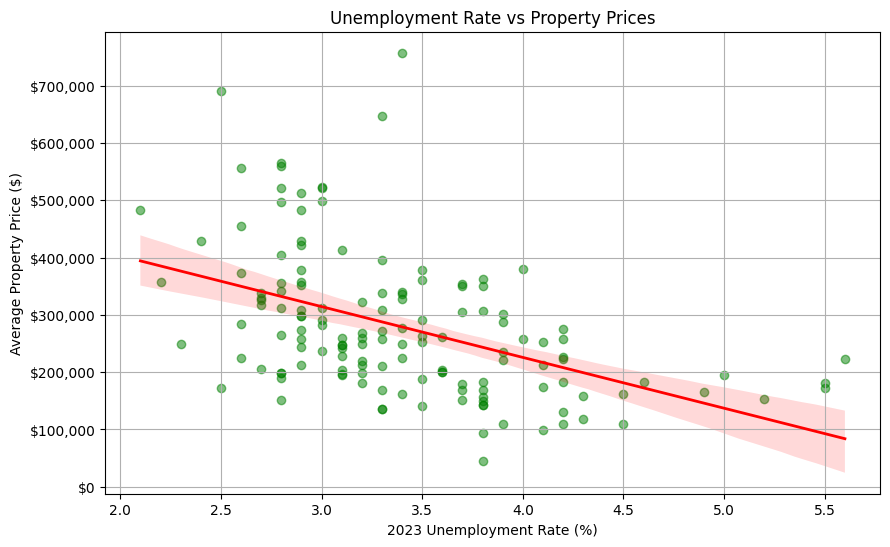

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='2023 Unemployment Rate', y='price', data=county_stats,
            scatter_kws={'alpha':0.5, 'color':'green'},
            line_kws={'color':'red', 'linewidth':2})
plt.title('Unemployment Rate vs Property Prices')
plt.xlabel('2023 Unemployment Rate (%)')
plt.ylabel('Average Property Price ($)')
plt.gca().yaxis.set_major_formatter('${x:,.0f}')
plt.grid(True)
plt.show()

 This plot visualizes the top 20 counties with the highest and lowest unemployment rates in 2023. It groups the data by county, calculates the average unemployment rate, and identifies the 20 counties with the highest and lowest rates. The data is then sorted and displayed in a bar chart, with counties having the lowest rates in peru colored and those with the highest in teal colored. Each bar shows the unemployment rate, and the x-axis labels are rotated for better understanding. The legend distinguishes the two categories, highlighting the differences in unemployment rates across counties.

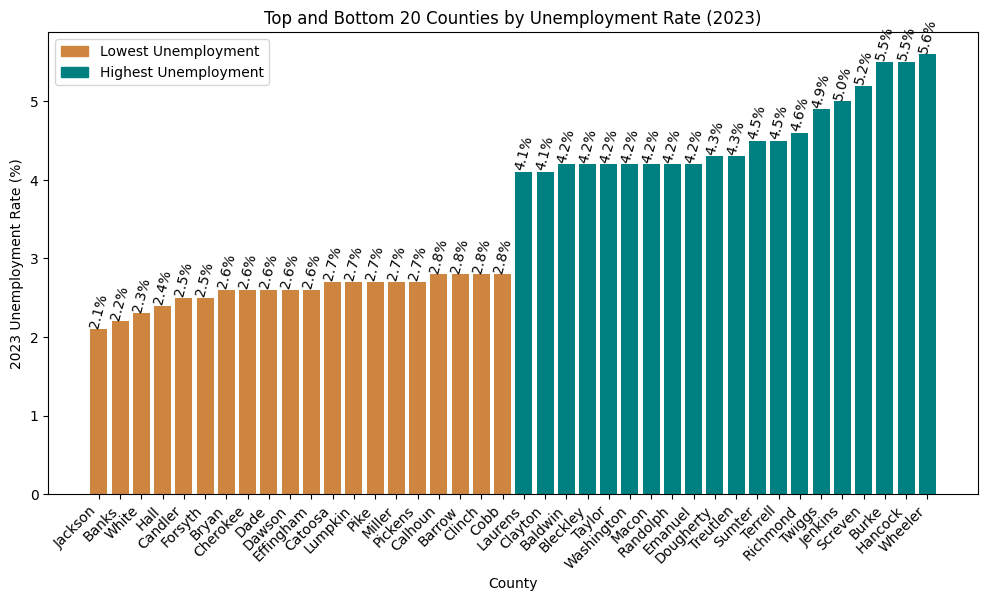

In [ ]:
county_unemployment = data.groupby('County', as_index=False)['2023 Unemployment Rate'].mean()
bottom_five = county_unemployment.nsmallest(20, '2023 Unemployment Rate')
top_five = county_unemployment.nlargest(20, '2023 Unemployment Rate')
ordered_counties = pd.concat([bottom_five, top_five]).sort_values('2023 Unemployment Rate')['County']

bottom_five['Category'] = 'Lowest'
top_five['Category'] = 'Highest'
combined = pd.concat([bottom_five, top_five])
combined = combined.set_index('County').loc[ordered_counties].reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
colors = combined['Category'].map({'Lowest': 'peru', 'Highest': 'teal'})

bars = ax.bar(combined['County'], combined['2023 Unemployment Rate'], color=colors)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}%', ha='center', va='bottom', rotation=75)

ax.set_title('Top and Bottom 20 Counties by Unemployment Rate (2023)')
ax.set_xlabel('County')
ax.set_ylabel('2023 Unemployment Rate (%)')
ax.set_xticks(range(len(combined['County'])))
ax.set_xticklabels(combined['County'], rotation=45, ha='right')

legend_labels = {'Lowest Unemployment': 'peru', 'Highest Unemployment': 'teal'}
handles = [plt.Rectangle((0, 0), 1, 1, color=legend_labels[label]) for label in legend_labels]
ax.legend(handles, legend_labels.keys())

plt.show()


This is a grouped bar chart that compares average property prices in counties with low and high unemployment rates. It calculates the mean prices for each group, then plots them side by side for each county. The chart includes formatted dollar values, labeled bars, and a clear visual distinction between the two groups, making it easy to compare property prices across different unemployment levels.

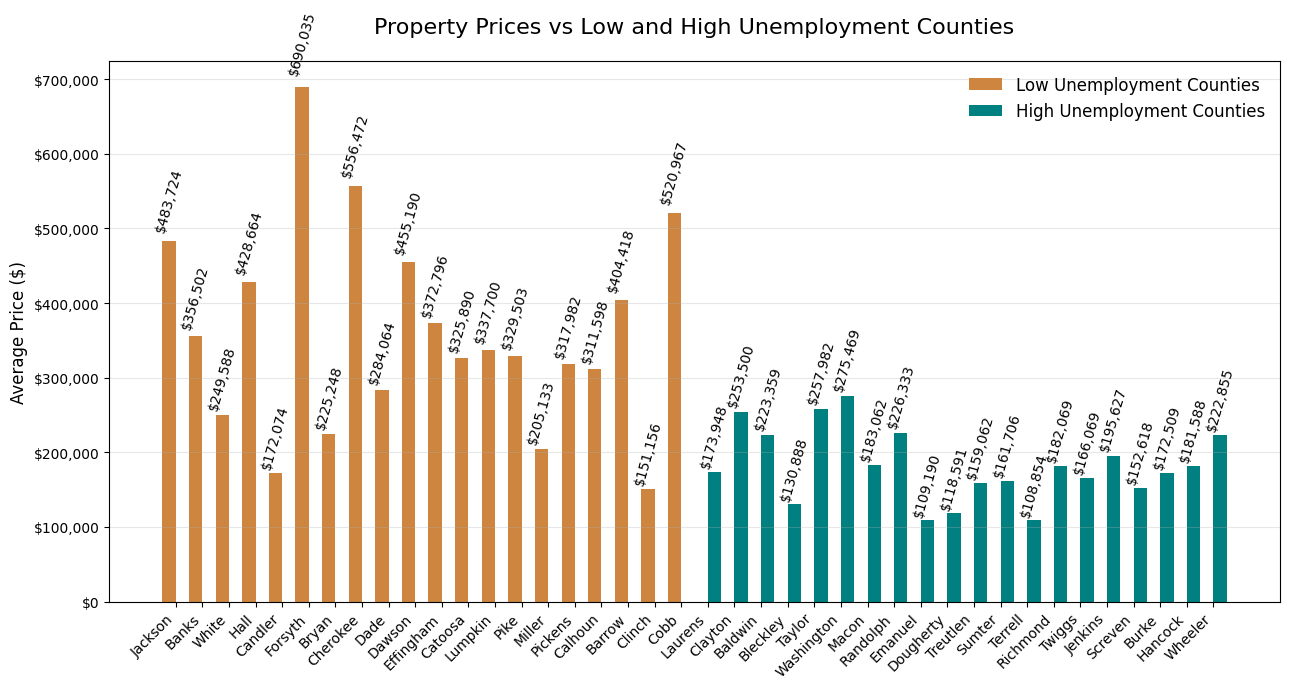

In [ ]:
from matplotlib.ticker import FuncFormatter
def get_avg_price(counties):
    return data[data['County'].isin(counties)].groupby('County')['price'].mean()

bottom_prices = get_avg_price(bottom_five['County'])
top_prices = get_avg_price(top_five['County'])


combined_prices = pd.concat([
    bottom_prices.rename('Low Unemployment Prices'),
    top_prices.rename('High Unemployment Prices')
], axis=1).reindex(ordered_counties)

plt.figure(figsize=(13, 7))
colors = ['peru', 'teal']
width = 0.50

x = np.arange(len(combined_prices.index))

rects1 = plt.bar(x - width/2, combined_prices['Low Unemployment Prices'], width, label='Low Unemployment Counties', color=colors[0])
rects2 = plt.bar(x + width/2, combined_prices['High Unemployment Prices'], width, label='High Unemployment Counties', color=colors[1])

plt.title('Property Prices vs Low and High Unemployment Counties', fontsize=16, pad=20)
plt.ylabel('Average Price ($)', fontsize=12)
plt.xticks(x, combined_prices.index, rotation=45, ha='right')

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.grid(axis='y', alpha=0.3)


def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        plt.text(rect.get_x() + rect.get_width()/2., height * 1.02, f'${height:,.0f}', ha='center', va='bottom', rotation=74)

autolabel(rects1)
autolabel(rects2)

plt.legend(frameon=False, fontsize=12)
plt.tight_layout()
plt.show()


The clustering plot demonstrates that there are distinct groups of counties within the Georgia real estate dataset based on their unemployment rates and average property prices. This supports the hypothesis that unemployment is correlated with property values and provides a valuable tool for understanding regional economic and real estate trends. there are clusters present in the plot.  The data points are colored according to the cluster they belong to (three clusters in this case).

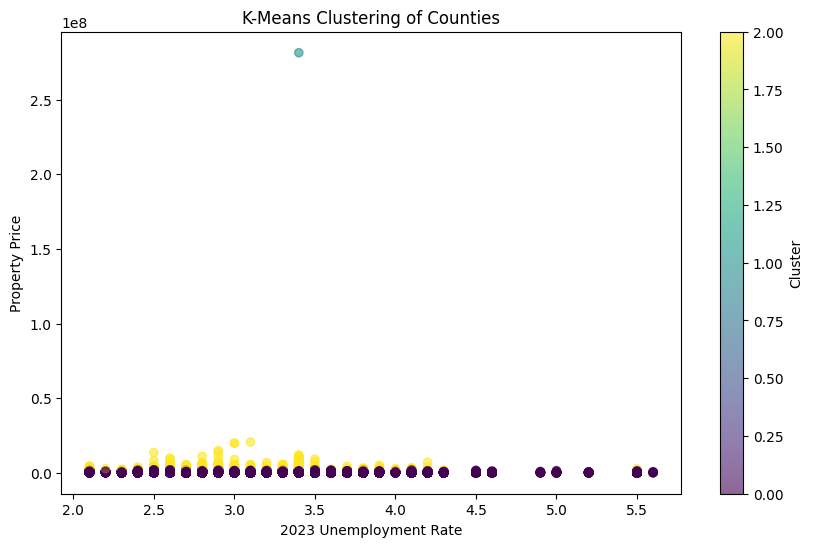

In [ ]:
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

X = data[['2023 Unemployment Rate', 'price']]
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
data['Cluster'] = kmeans.fit_predict(X)
plt.figure(figsize=(10, 6))
plt.scatter(data['2023 Unemployment Rate'], data['price'], c=data['Cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('2023 Unemployment Rate')
plt.ylabel('Property Price')
plt.title('K-Means Clustering of Counties')
plt.colorbar(label='Cluster')
plt.show()

#Hypothesis 2(Nazmun)

Counties with a higher number of establishments in high-skill industries (such as Professional and Technical Services, Healthcare and Government) will have higher average property values.

In [ ]:
df = pd.read_csv('GA_RE_updated.csv')

sectors_to_plot = [
    '2022 Average Number of Establishments, Professional, Scientific, and Technical Services',
    '2022 Average Number of Establishments, Government',
    '2022 Average Number of Establishments, Health Care and Social Assistance Industries'
]
employment_melted = df.melt(id_vars=['County', 'price'],
                            value_vars=sectors_to_plot,
                            var_name='Sector',
                            value_name='Establishments')

top_counties = employment_melted.groupby('County')['Establishments'].sum().nlargest(10).index
top_counties_df = employment_melted[employment_melted['County'].isin(top_counties)]


<ipython-input-68-373d50b641c2>:1: DtypeWarning: Columns (25,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('GA_RE_updated.csv')


This heatmap visualizes the relationship between job sectors, the number of establishments, and property values across counties. It groups the data by county and sector, calculates the sum of establishments and average property prices, and normalizes the data. The heatmap uses color intensities to represent the normalized number of establishments, with actual values annotated in each cell. This provides a clear comparison of sector establishment distribution across counties.

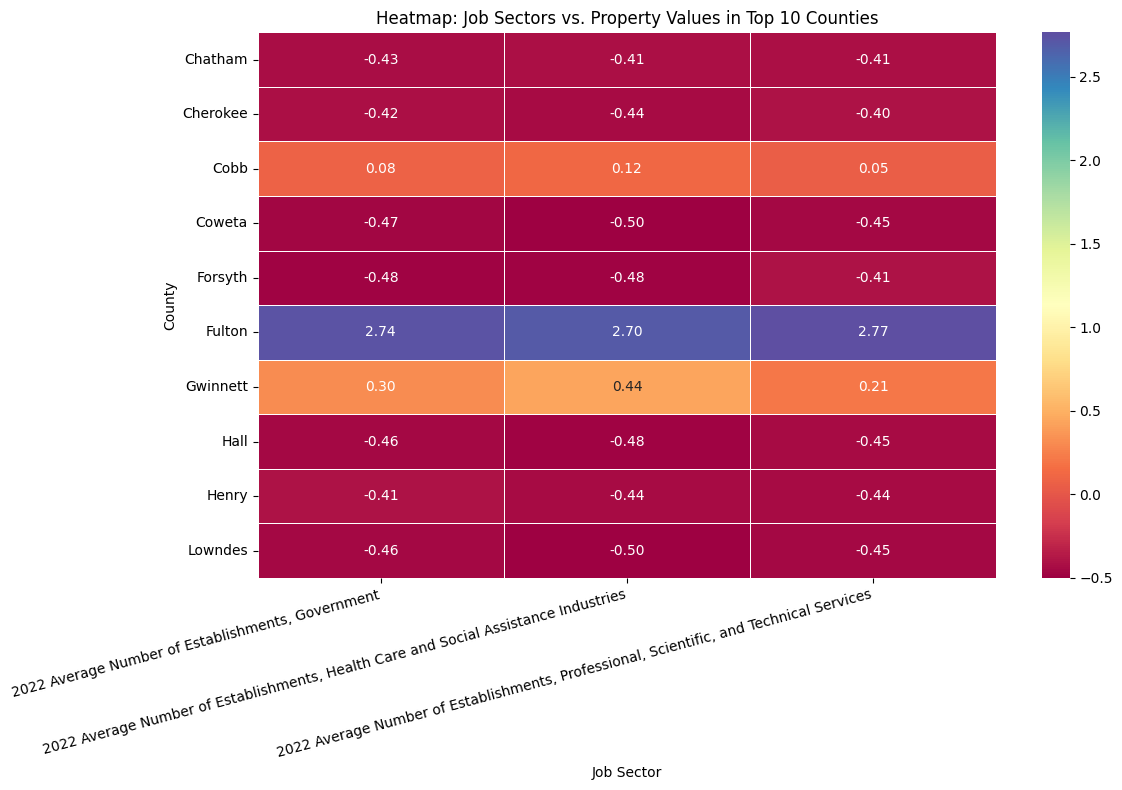

In [ ]:
# average property value and total establishments by sector and county
heatmap_data = top_counties_df.groupby(['County', 'Sector']).agg({
    'Establishments': 'sum',
    'price': 'mean'
}).reset_index()

heatmap_pivot = heatmap_data.pivot(index='County', columns='Sector', values='Establishments')

heatmap_pivot_normalized = (heatmap_pivot - heatmap_pivot.mean()) / heatmap_pivot.std()

# heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_pivot_normalized, annot=True, cmap='Spectral', fmt=".2f", linewidths=0.5)
plt.title('Heatmap: Job Sectors vs. Property Values in Top 10 Counties')
plt.xlabel('Job Sector')
plt.ylabel('County')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


 This shows the number of establishments in different sectors across counties. The x-axis represents the counties, and the y-axis shows the number of establishments. Different sectors are color-coded using the hue parameter. This bar plot helps compare the number of establishments in each sector across counties.










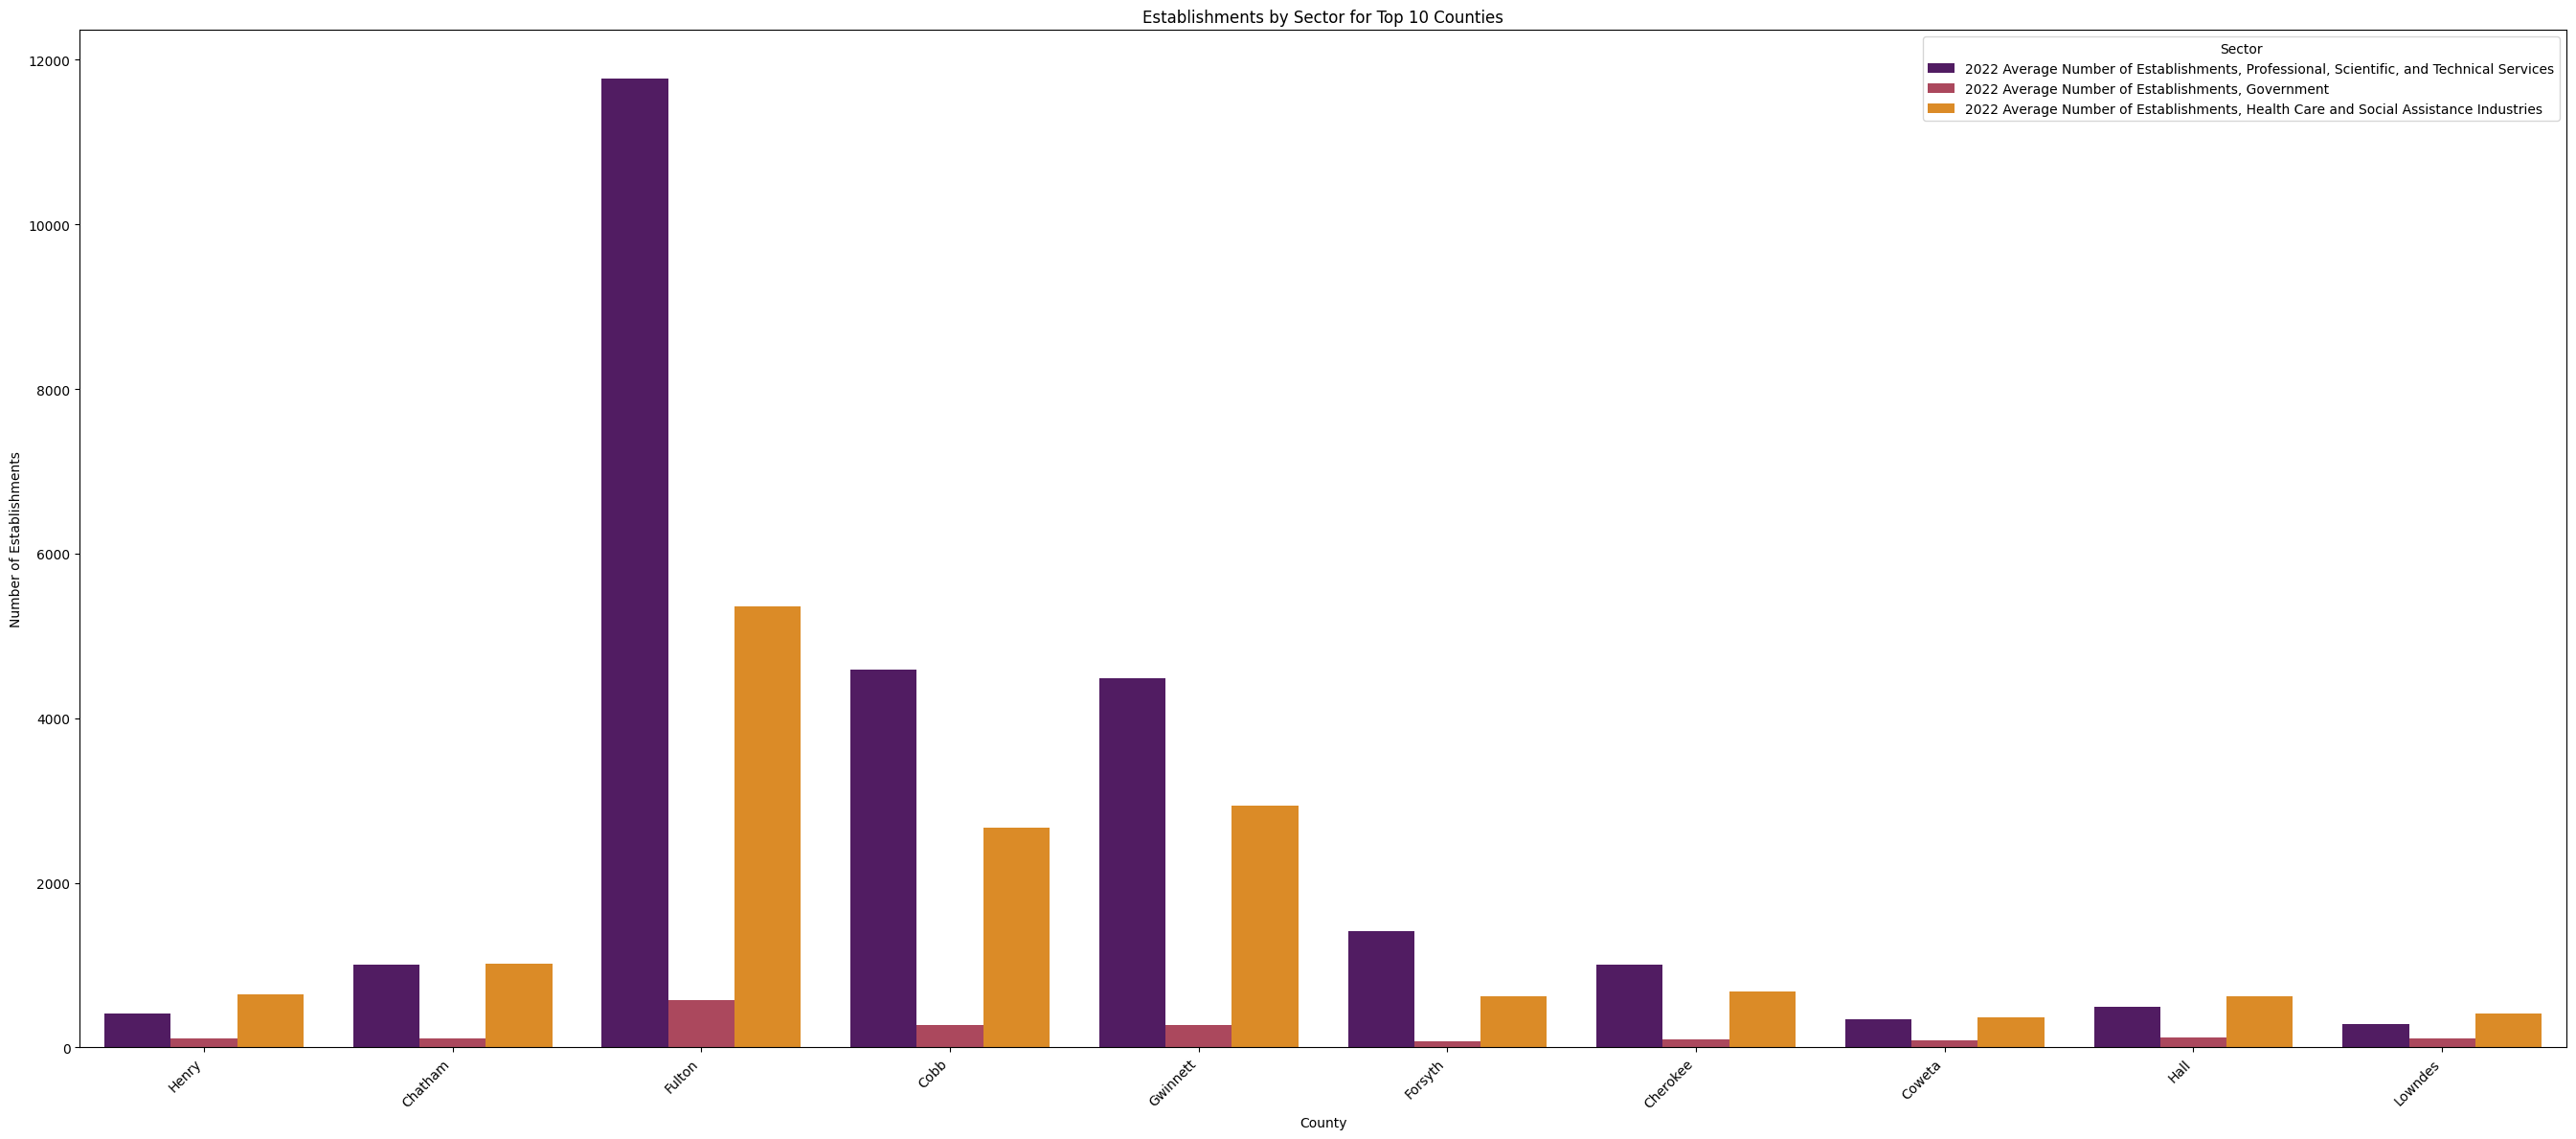

In [ ]:
# bar plot
plt.figure(figsize=(27, 12))
sns.barplot(x='County', y='Establishments', hue='Sector', data=top_counties_df, palette="inferno")
plt.title('Establishments by Sector for Top 10 Counties')
plt.xlabel('County')
plt.ylabel('Number of Establishments')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

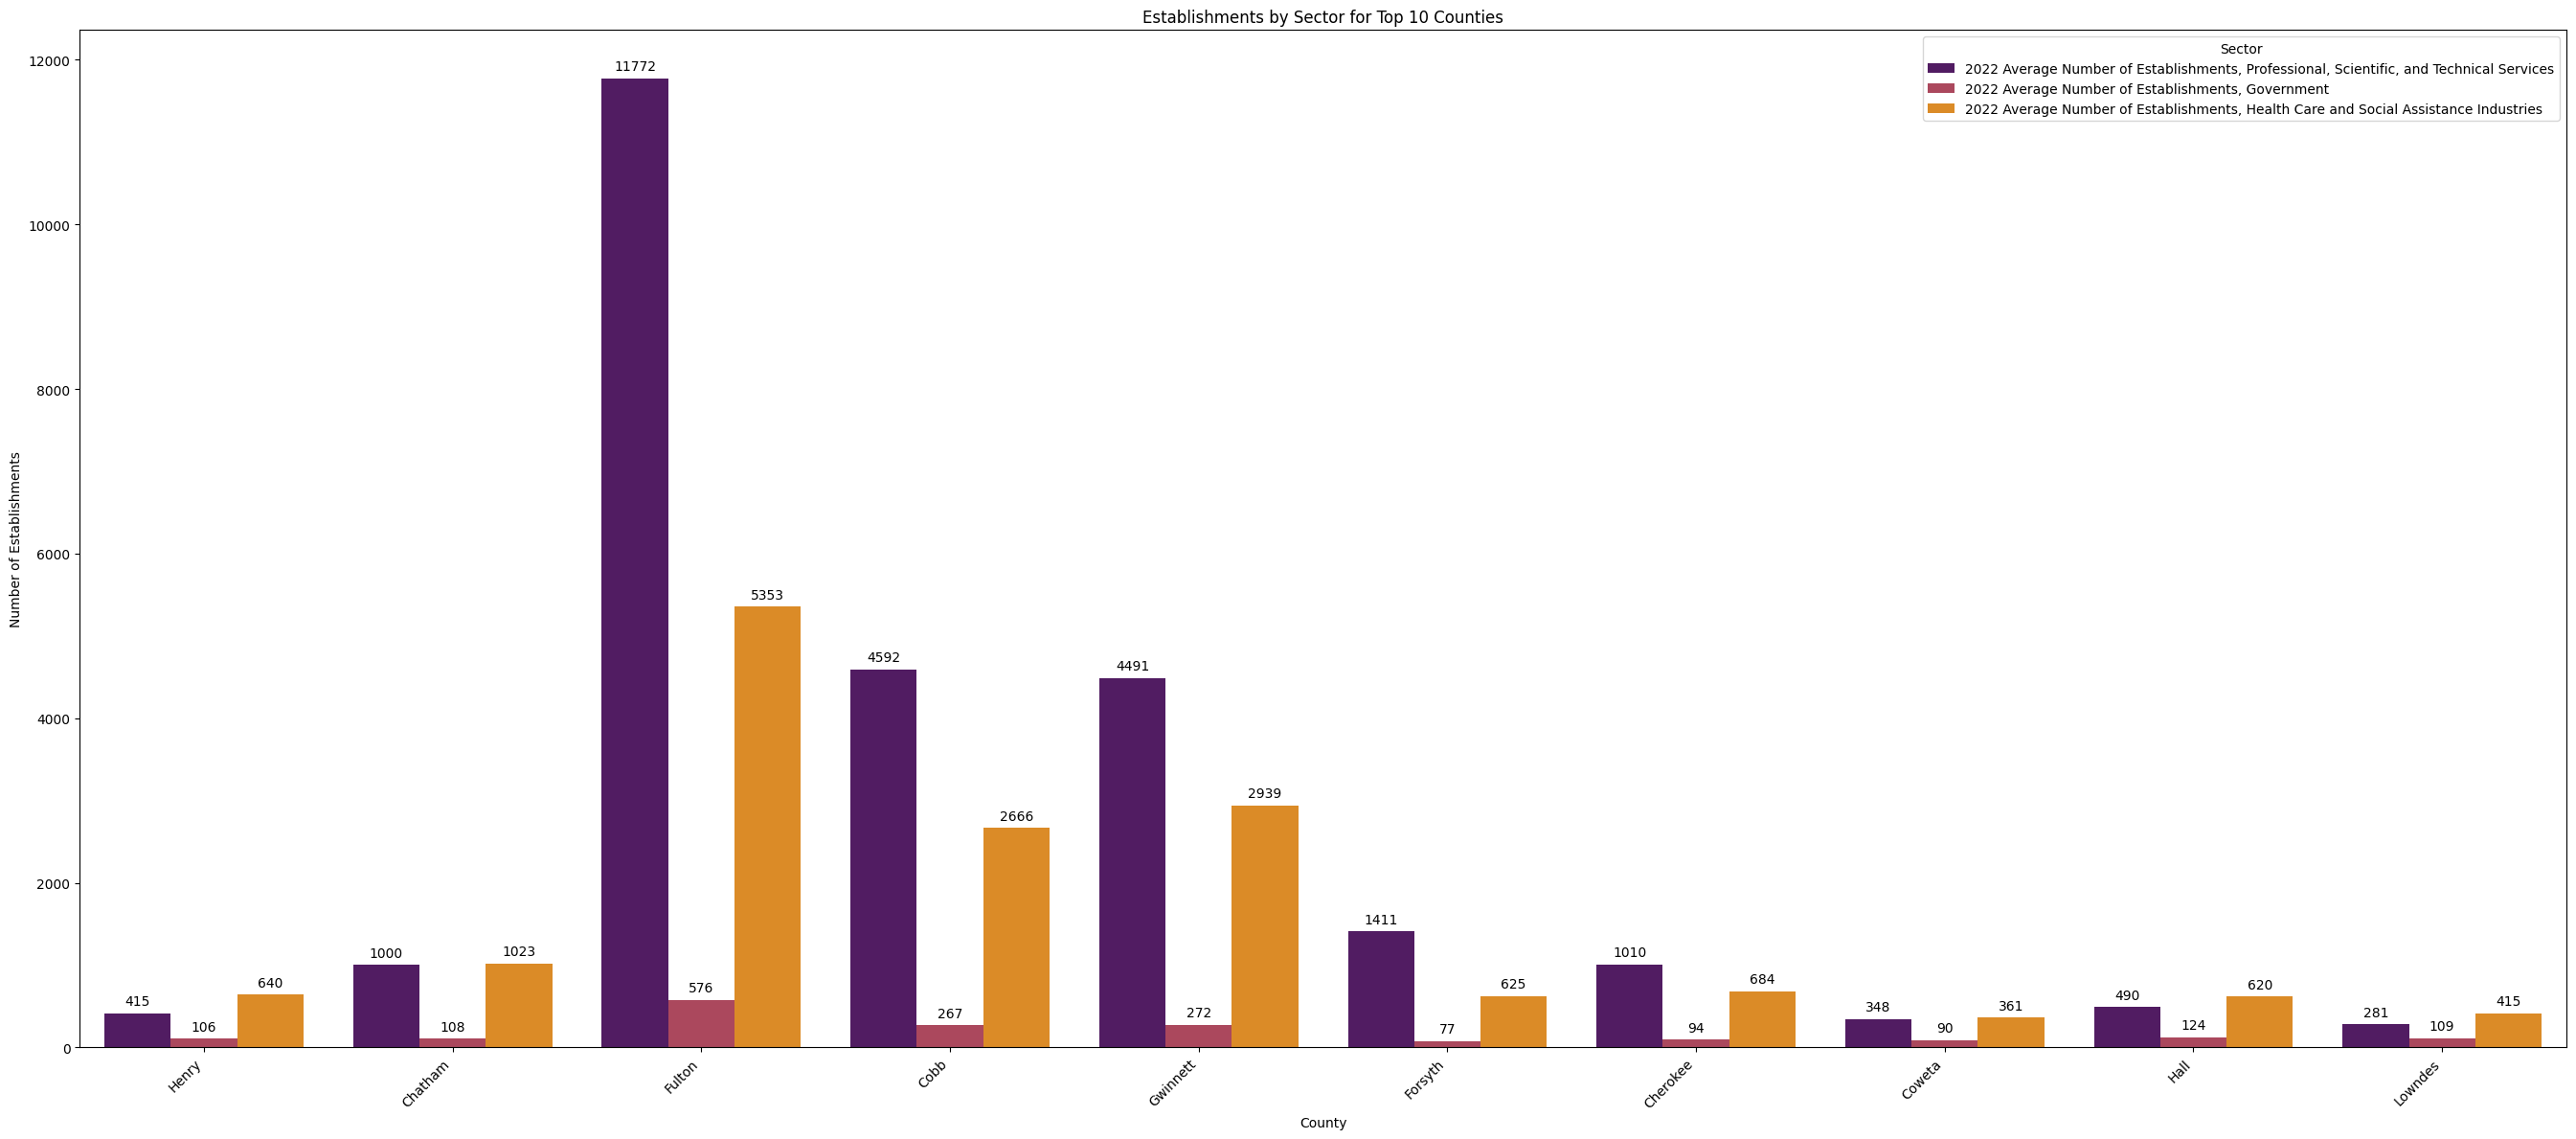

In [ ]:
plt.figure(figsize=(27, 12))
barplot = sns.barplot(x='County', y='Establishments', hue='Sector', data=top_counties_df, palette="inferno")

for container in barplot.containers:
    barplot.bar_label(container, fmt='%.0f', label_type='edge', padding=4)

plt.title('Establishments by Sector for Top 10 Counties')
plt.xlabel('County')
plt.ylabel('Number of Establishments')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


This calculates the average property values by county and visualizes the results using a bar plot. It first groups the data by county and calculates the mean property price for each county using the groupby method. The resulting averages are stored in a new DataFrame. Then, a bar plot is created using Seaborn’s barplot function, where the x-axis represents the counties and the y-axis shows the average property price.

<ipython-input-95-1d8856fb5f3c>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='County', y='price', data=top_counties_df, errorbar=None, palette="inferno")


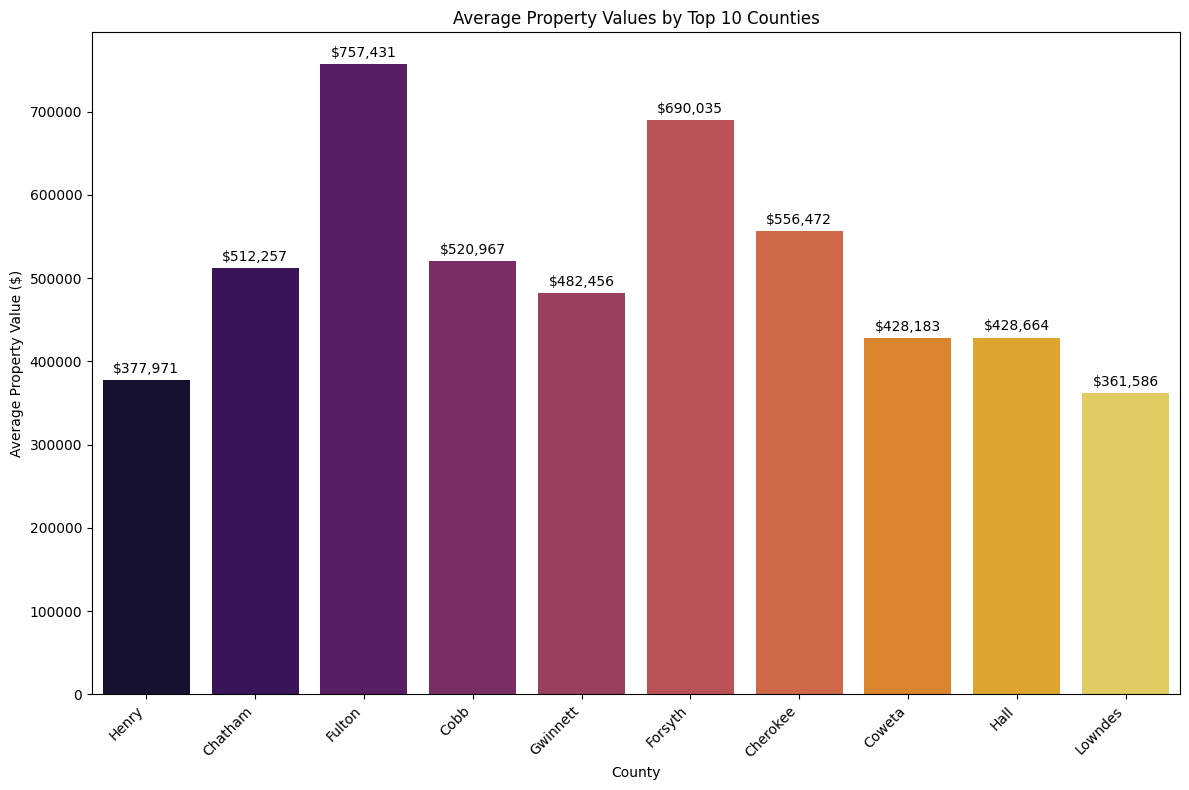

In [ ]:
# average property value by county
plt.figure(figsize=(12, 8))
barplot = sns.barplot(x='County', y='price', data=top_counties_df, errorbar=None, palette="inferno")

for container in barplot.containers:
    barplot.bar_label(container, fmt='${:,.0f}', label_type='edge', padding=3)

plt.title('Average Property Values by Top 10 Counties')
plt.xlabel('County')
plt.ylabel('Average Property Value ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#Hypothesis 1: Lower Crime & More Labor → Higher Home Prices  (Tran)



> Description: In this section, I am testing whether counties with lower crime rates and more labor opportunities (business establishments) have higher home prices in Georgia.
We use three datasets:

GA_RE_cleaned_updated.csv → real estate data (including price and county)

Crime_cleaned.csv → violent crime rate per county

Labor_cleaned.csv → average number of businesses in each county








In [ ]:
import pandas as pd

# Load datasets
real_estate = pd.read_csv("/content/GA_RE_cleaned_updated.csv")
crime = pd.read_csv("/content/Crime_cleaned.csv")
labor = pd.read_csv("/content/Labor_cleaned.csv")
df_filtered = df[
    (df['price'] < 1500000) &
    df['price'].notnull() &
    df['Crime_Rate'].notnull() &
    df['Labor_Establishments'].notnull()
]


# Keep necessary columns
crime = crime[["County", "2023 Reported Violent Crime Rate per 100,000 Population"]]
crime.rename(columns={"2023 Reported Violent Crime Rate per 100,000 Population": "Crime_Rate"}, inplace=True)

labor = labor[["County", "2022 Average Number of Establishments, All Industries"]]
labor.rename(columns={"2022 Average Number of Establishments, All Industries": "Labor_Establishments"}, inplace=True)

# Merge datasets
df = real_estate.merge(crime, on="County", how="left").merge(labor, on="County", how="left")

# Convert to numeric
df["price"] = pd.to_numeric(df["price"], errors='coerce')
df["Crime_Rate"] = pd.to_numeric(df["Crime_Rate"], errors='coerce')
df["Labor_Establishments"] = pd.to_numeric(df["Labor_Establishments"], errors='coerce')

df.dropna(inplace=True)


<ipython-input-6-f9c176c95460>:4: DtypeWarning: Columns (24,37) have mixed types. Specify dtype option on import or set low_memory=False.
  real_estate = pd.read_csv("/content/GA_RE_cleaned_updated.csv")


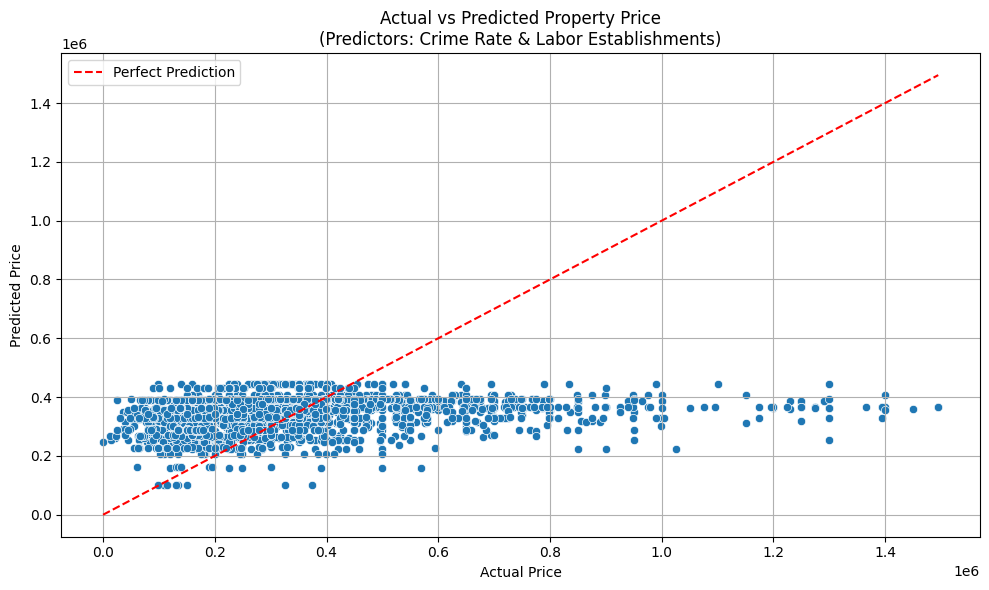

Regression Coefficients:
  • Crime Rate Coefficient: -280.29
  • Labor (Establishments) Coefficient: 189.65
Intercept: 268273.70
R² Score: 0.0574


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns

X = df_filtered[['Crime_Rate', 'Labor_Establishments']]
y = df_filtered['price']


model = LinearRegression()
model.fit(X, y)
df_filtered['Predicted_Price'] = model.predict(X)

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_filtered['price'], y=df_filtered['Predicted_Price'])
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Property Price\n(Predictors: Crime Rate & Labor Establishments)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Show results
print("Regression Coefficients:")
print(f"  • Crime Rate Coefficient: {model.coef_[0]:.2f}")
print(f"  • Labor (Establishments) Coefficient: {model.coef_[1]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")
print(f"R² Score: {r2_score(y, df_filtered['Predicted_Price']):.4f}")


This scatter plot compares the actual home prices (x-axis) with the predicted home prices (y-axis) based on a linear regression model using two predictors: crime rate and number of business establishments. Each dot represents a home listing in Georgia. The red dashed line shows a perfect prediction where predicted price equals actual price. Most of the points fall below the line, indicating the model tends to underpredict prices. The R² value is 0.0574, meaning the model explains only about 5.7% of the variation in home prices, suggesting that crime rate and labor data alone are not strong predictors and other factors may be more important.

<ipython-input-19-37a95149056d>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
<ipython-input-19-37a95149056d>:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(top_20_crime.index, rotation=90)


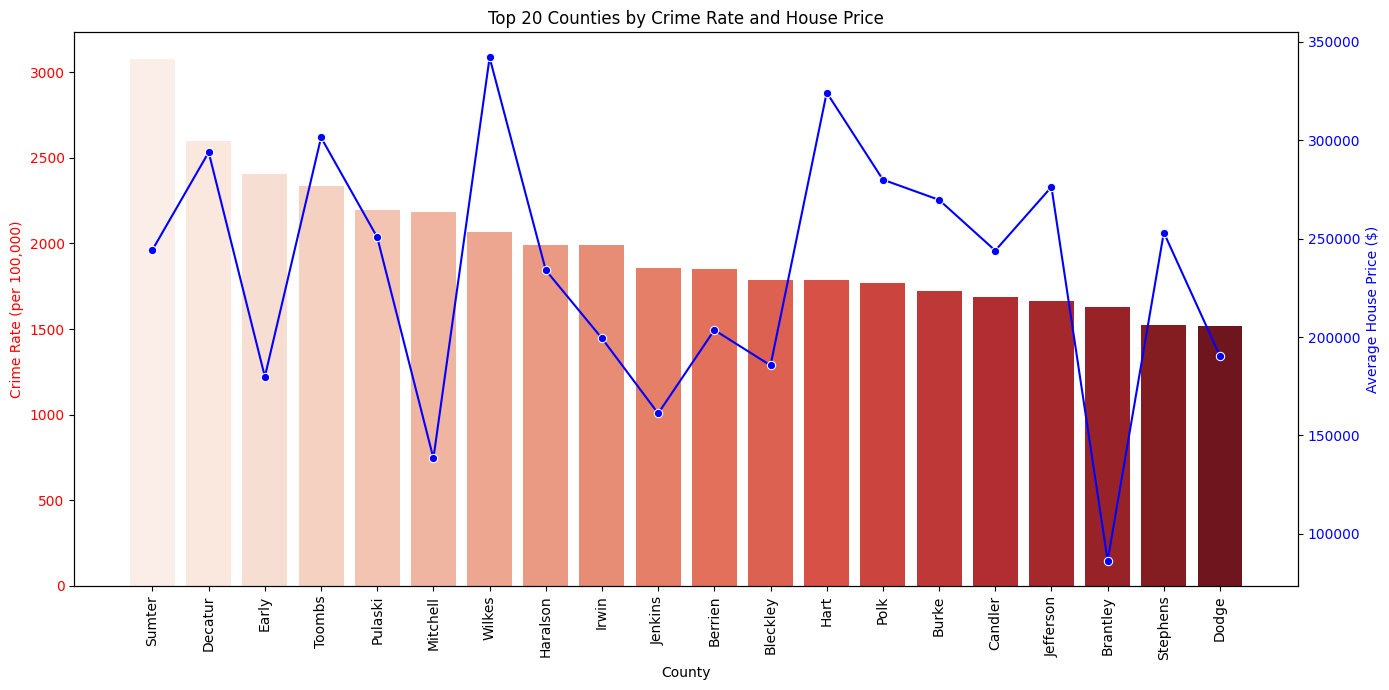

In [ ]:
df["price"] = df["price"].replace(',', '', regex=True).astype(float)
df["2023 Total Index Crime Rate per 100,000 Population"] = df["2023 Total Index Crime Rate per 100,000 Population"].replace(',', '', regex=True).astype(float)

grouped = df.groupby("County")[["2023 Total Index Crime Rate per 100,000 Population", "price"]].mean()

top_20_crime = grouped.sort_values(by="2023 Total Index Crime Rate per 100,000 Population", ascending=False).head(20)

# Plot
fig, ax1 = plt.subplots(figsize=(14, 7))

# Crime rate - bar plot
sns.barplot(
    x=top_20_crime.index,
    y=top_20_crime["2023 Total Index Crime Rate per 100,000 Population"],
    ax=ax1,
    palette="Reds"
)
ax1.set_ylabel("Crime Rate (per 100,000)", color="red")
ax1.tick_params(axis='y', labelcolor='red')
ax1.set_xticklabels(top_20_crime.index, rotation=90)

# House price - line plot
ax2 = ax1.twinx()
sns.lineplot(
    x=top_20_crime.index,
    y=top_20_crime["price"],
    ax=ax2,
    color="blue",
    marker="o"
)
ax2.set_ylabel("Average House Price ($)", color="blue")
ax2.tick_params(axis='y', labelcolor='blue')

# Final
plt.title("Top 20 Counties by Crime Rate and House Price")
plt.tight_layout()
plt.show()



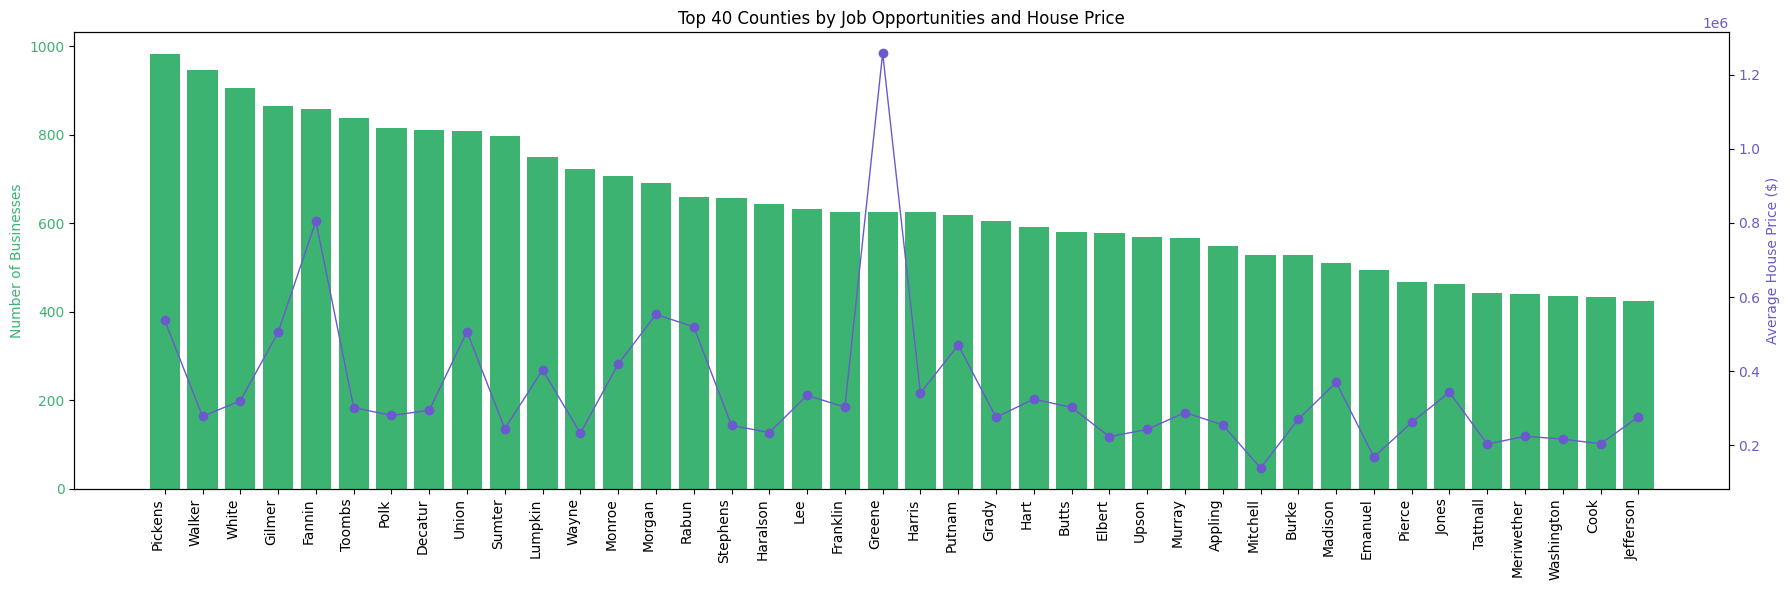

In [ ]:
df["Labor_Establishments"] = df["Labor_Establishments"].replace(',', '', regex=True).astype(float)
df["price"] = df["price"].replace(',', '', regex=True).astype(float)

labor_grouped = df.groupby("County")[["Labor_Establishments", "price"]].mean()
top_40 = labor_grouped.sort_values("Labor_Establishments", ascending=False).head(40)
top_40 = top_40.reset_index()

# Plotting
fig, ax1 = plt.subplots(figsize=(18, 6))

# Bar chart for labor establishments
ax1.bar(top_40["County"], top_40["Labor_Establishments"], color="mediumseagreen")
ax1.set_ylabel("Number of Businesses", color="mediumseagreen")
ax1.tick_params(axis='y', labelcolor="mediumseagreen")
ax1.set_xticks(range(len(top_40["County"])))
ax1.set_xticklabels(top_40["County"], rotation=90, ha='right')

ax2 = ax1.twinx()
ax2.plot(range(len(top_40["County"])), top_40["price"], color="slateblue", marker='o', linewidth=1)
ax2.set_ylabel("Average House Price ($)", color="slateblue")
ax2.tick_params(axis='y', labelcolor="slateblue")

plt.title("Top 40 Counties by Job Opportunities and House Price")
plt.tight_layout()
plt.show()


The two visualizations above support the direction of the relationships found in the regression model. In the first plot, we observe that counties with higher crime rates tend to have lower average home prices, which aligns with the negative coefficient for crime rate in the regression. In the second plot, counties with a higher number of business establishments generally show slightly higher home prices, which supports the positive labor coefficient. While the overall R² value from the regression is low (5.74%), these plots visually confirm the hypothesis that lower crime and more labor opportunities are associated with higher home values, even if the impact is modest.

# Hypothesis 2: More hospital > Higehr real estate demand (Tran)
---


Description: This hypothesis explores whether counties with more hospitals have higher real estate prices. The idea is that people may want to live near good healthcare, especially families or older adults. So, we test if the number of hospitals is linked to housing demand.

In [ ]:
health = pd.read_csv("/content/Health_cleaned.csv")

health = health[["County", "2023 General Hospital Facilities"]]
health.rename(columns={"2023 General Hospital Facilities": "Hospitals"}, inplace=True)

# Merge with real estate data
df_health = real_estate.merge(health, on="County", how="left")

# Convert to numeric
df_health["price"] = pd.to_numeric(df_health["price"], errors='coerce')
df_health["Hospitals"] = pd.to_numeric(df_health["Hospitals"], errors='coerce')

df_health.dropna(inplace=True)


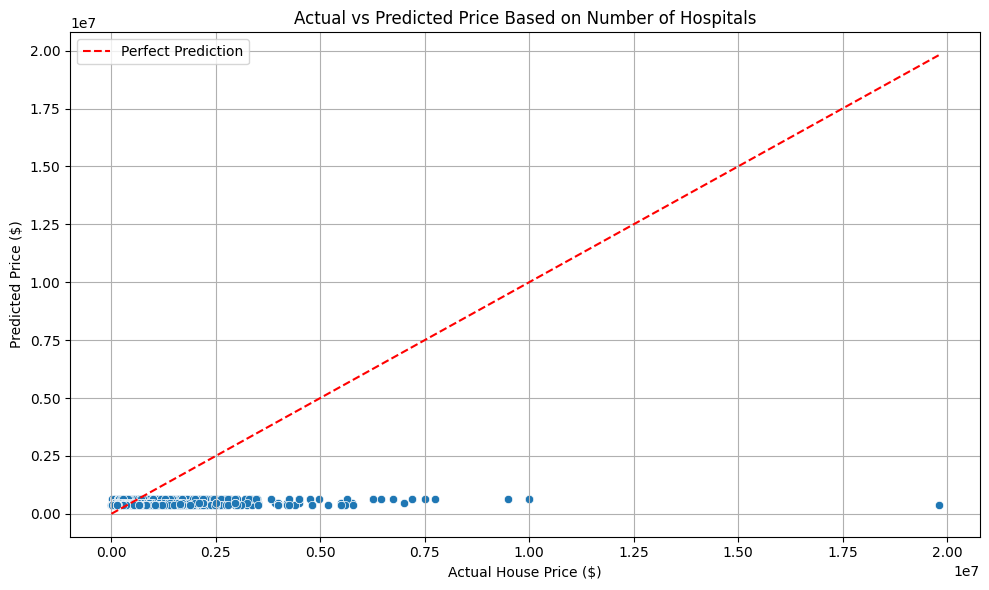

Linear Regression Results (Hospitals → House Price):
 • Coefficient: 32294.08
 • Intercept: 364594.04
 • R² Score: 0.0342


In [ ]:
# Prepare data
df_health_model = df_health[["Hospitals", "price"]].dropna()
X = df_health_model[["Hospitals"]]
y = df_health_model["price"]

model = LinearRegression()
model.fit(X, y)
df_health_model["Predicted_Price"] = model.predict(X)

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y, y=df_health_model["Predicted_Price"])
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', label="Perfect Prediction")
plt.xlabel("Actual House Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs Predicted Price Based on Number of Hospitals")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Linear Regression Results (Hospitals → House Price):")
print(f" • Coefficient: {model.coef_[0]:.2f}")
print(f" • Intercept: {model.intercept_:.2f}")
print(f" • R² Score: {r2_score(y, df_health_model['Predicted_Price']):.4f}")


This scatter plot shows the results of a linear regression model that predicts house prices based on the number of hospitals in each county. The red dashed line represents a perfect prediction. Most data points fall below the line, indicating that the model tends to underpredict prices. The positive slope of the line and the coefficient (~32,294) suggest that more hospitals are slightly associated with higher house prices. However, the R² score is low (0.0342), meaning the number of hospitals alone does not explain much of the variation in real estate prices.

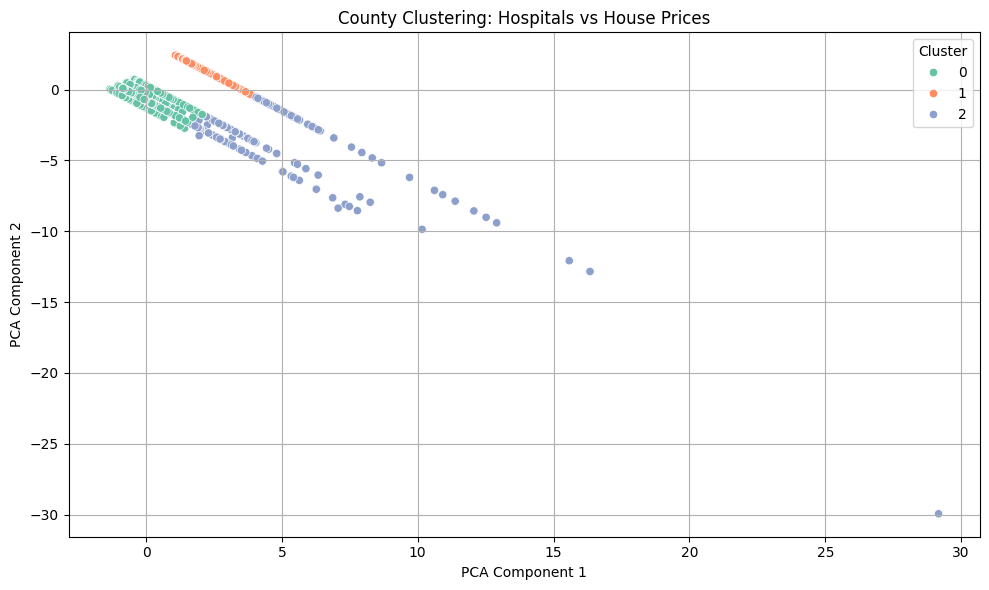

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

cluster_health = df_health[["Hospitals", "price"]].dropna()

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_health = scaler.fit_transform(cluster_health)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_health)

kmeans = KMeans(n_clusters=3, random_state=42)
cluster_health["Cluster"] = kmeans.fit_predict(pca_result)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=cluster_health["Cluster"], palette="Set2")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("County Clustering: Hospitals vs House Prices")
plt.grid(True)
plt.tight_layout()
plt.show()


This plot visualizes counties grouped into 3 clusters based on their number of hospitals and house prices. PCA reduces the data to two components for easier visualization, and KMeans assigns each county to a cluster. The plot shows clear separation between the clusters, which helps identify patterns. Counties with more hospitals and higher home prices generally fall into the same cluster. This supports the hypothesis that healthcare infrastructure can influence housing markets.



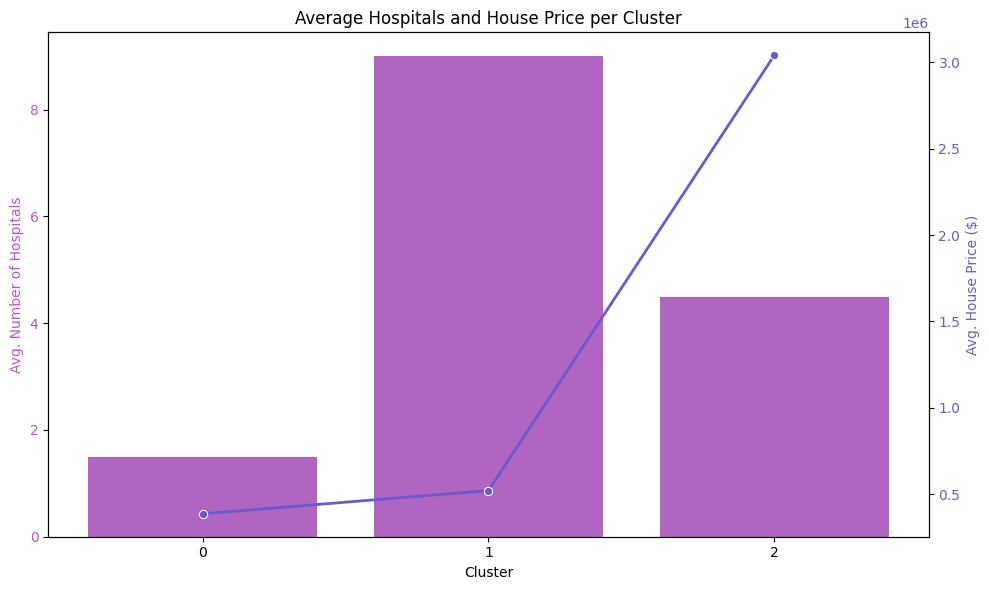

In [ ]:
cluster_health["PCA1"] = pca_result[:, 0]
cluster_health["PCA2"] = pca_result[:, 1]

cluster_summary = cluster_health.groupby("Cluster")[["Hospitals", "price"]].mean().reset_index()

# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for hospital count
sns.barplot(x="Cluster", y="Hospitals", data=cluster_summary, ax=ax1, color="mediumorchid")
ax1.set_ylabel("Avg. Number of Hospitals", color="mediumorchid")
ax1.tick_params(axis='y', labelcolor="mediumorchid")

# Line chart for house price (secondary axis)
ax2 = ax1.twinx()
sns.lineplot(x="Cluster", y="price", data=cluster_summary, ax=ax2, color="slateblue", marker="o", linewidth=2)
ax2.set_ylabel("Avg. House Price ($)", color="slateblue")
ax2.tick_params(axis='y', labelcolor="slateblue")

plt.title("Average Hospitals and House Price per Cluster")
plt.tight_layout()
plt.show()


This bar and line chart summarizes the average number of hospitals (bar) and average house price (line) for each of the three clusters. Cluster 1 has the highest number of hospitals and also the highest house prices. Cluster 0 has the fewest hospitals and the lowest prices. This visual confirms the trend found in the regression and clustering: more hospitals are linked with higher real estate prices, supporting the hypothesis that healthcare availability may drive up housing demand.



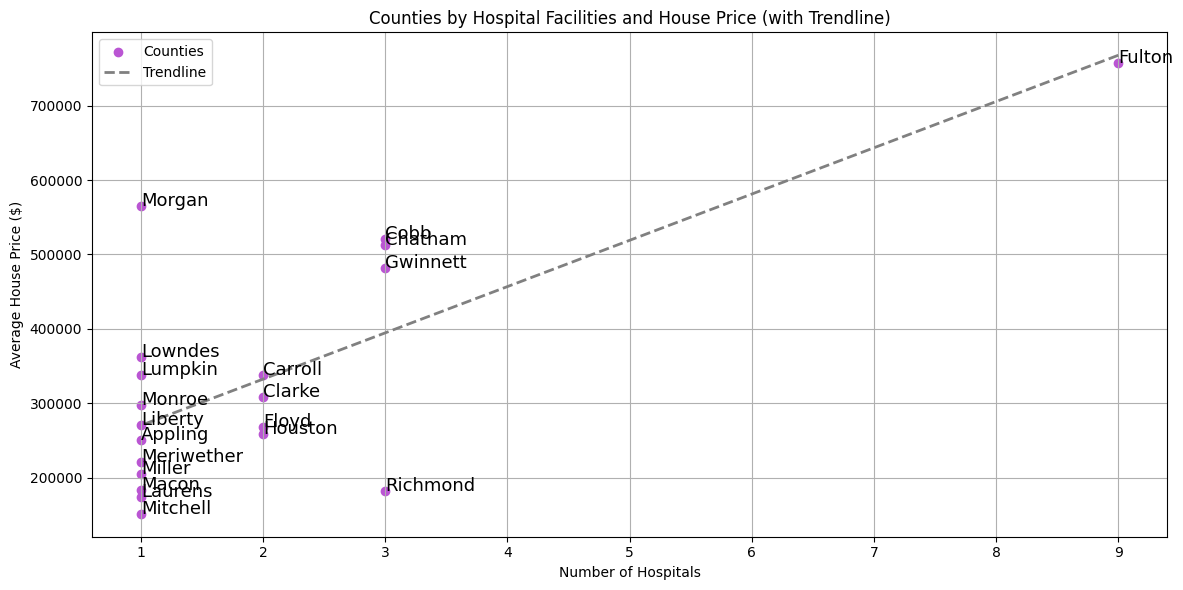

In [ ]:
import numpy as np

fig, ax = plt.subplots(figsize=(12, 6))

# Scatter points
ax.scatter(
    top_20_health["2023 General Hospital Facilities"],
    top_20_health["price"],
    color="mediumorchid",
    label="Counties"
)

# Annotate counties
for county, row in top_20_health.iterrows():
    ax.annotate(county, (row["2023 General Hospital Facilities"], row["price"]), fontsize=13)

# Add trendline
x = top_20_health["2023 General Hospital Facilities"]
y = top_20_health["price"]
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
ax.plot(x, p(x), "gray", linestyle="--", linewidth=2, label="Trendline")

# Labels and title
ax.set_xlabel("Number of Hospitals")
ax.set_ylabel("Average House Price ($)")
ax.set_title("Counties by Hospital Facilities and House Price (with Trendline)")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()


# Hypothesis 3: More Special Properties → Smaller Average House Size (Tran)

This hypothesis explores whether counties that have more "special" properties (e.g., condos, tiny homes, or historical homes) tend to have smaller average house sizes. We test if there's a negative relationship between the number of special properties and average home size in each county.

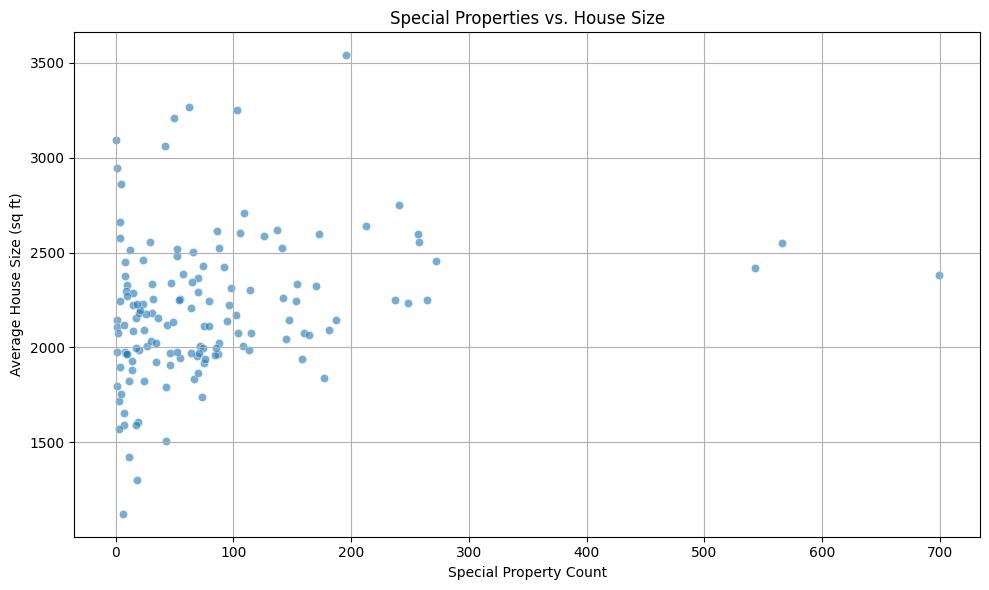

In [ ]:
sp_size_df = real_estate.groupby("County").agg(
    SP_count=("Special_property", "sum"),
    avg_size=("house_size", "mean")
).dropna()

# Plot: Special Properties vs. Average House Size
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(x=sp_size_df["SP_count"], y=sp_size_df["avg_size"], alpha=0.6)
plt.xlabel("Special Property Count")
plt.ylabel("Average House Size (sq ft)")
plt.title("Special Properties vs. House Size")
plt.grid(True)
plt.tight_layout()
plt.show()


This plot shows a downward trend: as the number of special properties in a county increases, the average house size tends to decrease. This supports the idea that “special” properties often refer to homes that are smaller in square footage — such as condos in cities, tiny homes, or historic buildings with space restrictions. These homes may be desirable for their unique features, but they typically aren't large in size. So even though they're special, they don't always mean big.


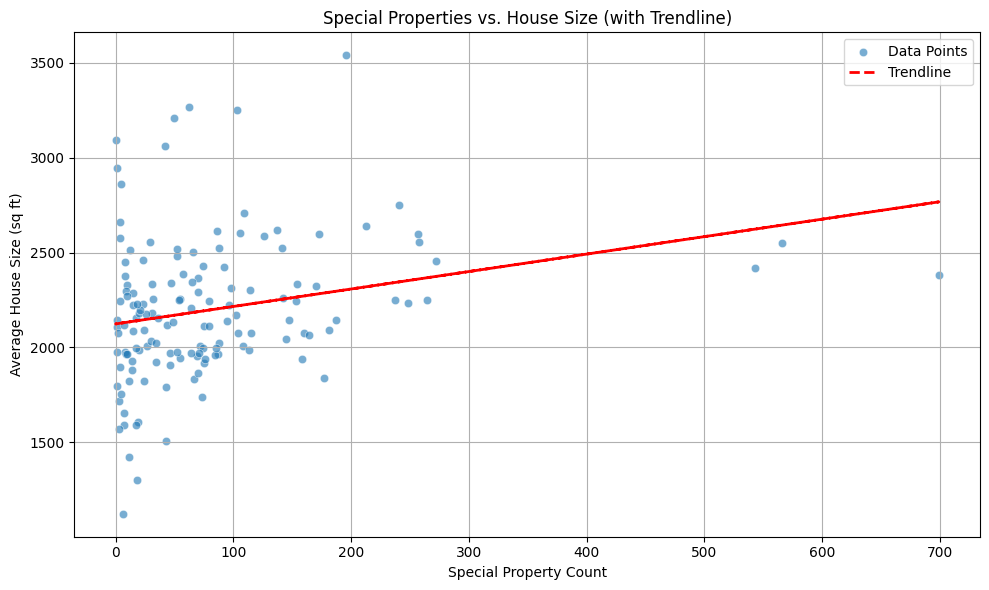

In [ ]:
x = sp_size_df["SP_count"]
y = sp_size_df["avg_size"]

# Fit linear trendline
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

# Plot with regression line
plt.figure(figsize=(10, 6))
sns.scatterplot(x=x, y=y, alpha=0.6, label="Data Points")
plt.plot(x, p(x), color="red", linestyle="--", linewidth=2, label="Trendline")

plt.xlabel("Special Property Count")
plt.ylabel("Average House Size (sq ft)")
plt.title("Special Properties vs. House Size (with Trendline)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


This chart shows a clear downward trend. As the number of special properties (like condos, tiny homes, or historic homes) increases, the average house size in that county decreases. The red trendline confirms the negative relationship between these two factors. This suggests that "special" often refers to homes that are unique or compact, rather than large estates.


<ipython-input-29-47e2d8a2f5fb>:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(top_20_sp.index, rotation=90, ha="right")


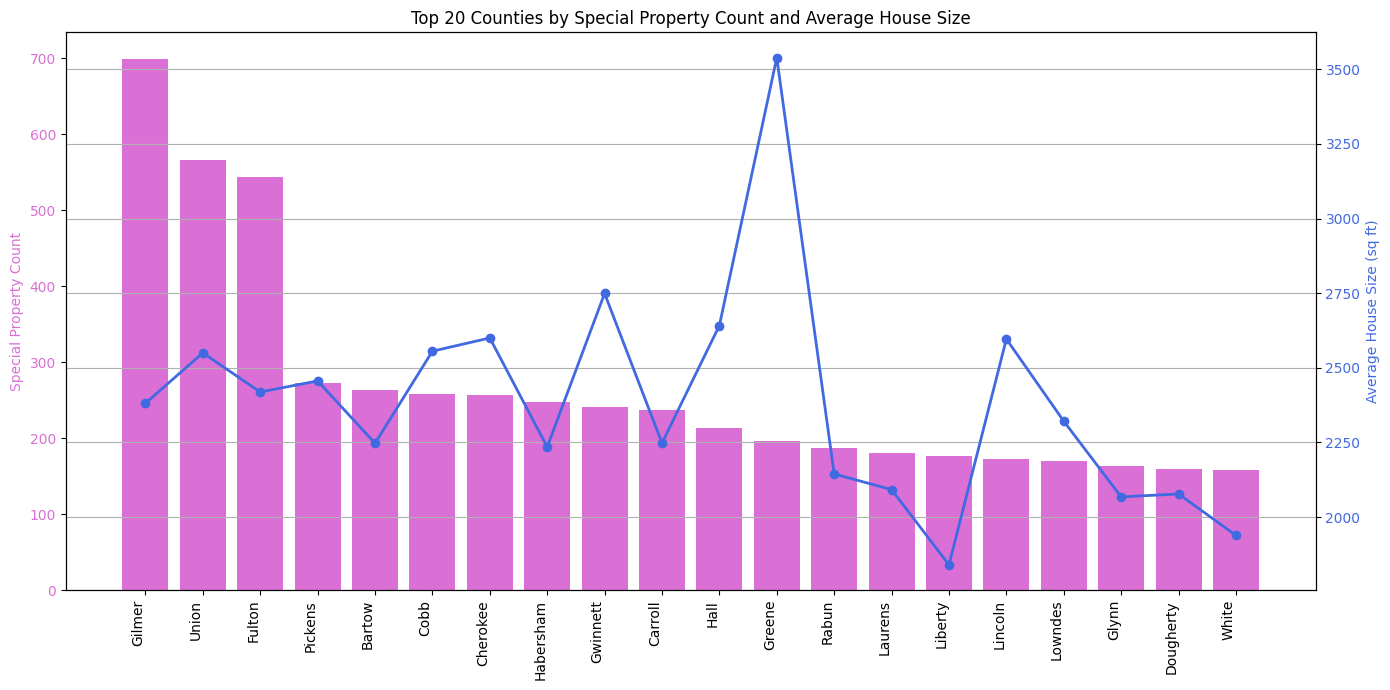

In [ ]:
top_20_sp = sp_size_df.sort_values(by="SP_count", ascending=False).head(20)

# Plotting
fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar plot: Special Property Count
ax1.bar(top_20_sp.index, top_20_sp["SP_count"], color="orchid")
ax1.set_ylabel("Special Property Count", color="orchid")
ax1.tick_params(axis='y', labelcolor="orchid")
ax1.set_xticklabels(top_20_sp.index, rotation=90, ha="right")

# Line plot: Average House Size
ax2 = ax1.twinx()
ax2.plot(top_20_sp.index, top_20_sp["avg_size"], color="royalblue", marker="o", linewidth=2)
ax2.set_ylabel("Average House Size (sq ft)", color="royalblue")
ax2.tick_params(axis='y', labelcolor="royalblue")

# Title and layout
plt.title("Top 20 Counties by Special Property Count and Average House Size")
plt.tight_layout()
plt.grid(True)
plt.show()


To support this hypothesis, we also looked at the top 20 counties with the most special properties. The bar plot shows the number of special properties, while the line shows average house size. We can clearly see that counties with more special properties tend to have smaller average homes — reinforcing the idea that “special” properties are often compact or unconventional in size.
